# 🚀 Dự đoán nồng độ khí CO trong không khí (Bài toán hồi quy)

## 🎯 Mô tả bài toán

Trong đề tài này, chúng tôi xây dựng một mô hình học máy nhằm dự đoán nồng độ khí Carbon Monoxide (CO) trong không khí dựa trên dữ liệu thu thập từ các cảm biến môi trường.

Chất lượng không khí là một yếu tố quan trọng ảnh hưởng trực tiếp đến sức khỏe con người và môi trường sống. Trong đó, Carbon Monoxide (CO) là một loại khí độc không màu, không mùi, có thể gây nguy hiểm nghiêm trọng nếu tồn tại ở nồng độ cao.

Thông qua việc phân tích các tín hiệu từ cảm biến như nồng độ các khí khác (NOx, NO2, Benzene), nhiệt độ, độ ẩm và thời gian đo, mô hình có thể học được mối quan hệ giữa các yếu tố này và nồng độ CO trong không khí.

---

## 📌 Mục tiêu

* Dự đoán giá trị **CO(GT)** dựa trên các đặc trưng cảm biến
* Phân tích mức độ ảnh hưởng của các yếu tố môi trường đến nồng độ CO
* Xây dựng và so sánh nhiều mô hình hồi quy khác nhau
* Đánh giá hiệu năng mô hình thông qua các chỉ số như **Mean Squared Error (MSE)** và **R² Score**

---

## 🧠 Loại bài toán

* Đây là bài toán **Học có giám sát (Supervised Learning)**
* Thuộc dạng **Hồi quy (Regression)** vì biến mục tiêu là giá trị liên tục

---

## 📊 Kết quả kỳ vọng

* Xây dựng được mô hình có khả năng dự đoán chính xác nồng độ CO
* Xác định được các yếu tố quan trọng ảnh hưởng đến ô nhiễm không khí
* So sánh hiệu năng giữa các mô hình như Linear Regression, Random Forest và XGBoost
* Đưa ra nhận xét về khả năng ứng dụng của mô hình trong thực tế


## 1.2 Mô tả dữ liệu

### 📂 Nguồn dữ liệu

Bộ dữ liệu được sử dụng trong đề tài là **Air Quality Dataset** từ UCI Machine Learning Repository. Bộ dữ liệu này được thu thập từ một hệ thống cảm biến đặt tại một thành phố ở Ý, nhằm ghi nhận các thông số liên quan đến chất lượng không khí theo thời gian.

---

### 📊 Tổng quan dữ liệu

* Số lượng mẫu: ~9,358 bản ghi
* Số lượng thuộc tính: 15+ biến
* Tần suất ghi nhận: theo giờ
* Dữ liệu bao gồm:

  * Thông tin thời gian (Date, Time)
  * Nồng độ các chất khí
  * Tín hiệu từ các cảm biến
  * Các yếu tố môi trường như nhiệt độ, độ ẩm

---

### 🧾 Các thuộc tính chính

| Tên thuộc tính | Ý nghĩa                                     |
| -------------- | ------------------------------------------- |
| Date, Time     | Thời điểm ghi nhận dữ liệu                  |
| CO(GT)         | Nồng độ khí Carbon Monoxide (biến mục tiêu) |
| PT08.S1(CO)    | Tín hiệu cảm biến liên quan đến CO          |
| NMHC(GT)       | Nồng độ Hydrocarbon không metan             |
| C6H6(GT)       | Nồng độ Benzene                             |
| NOx(GT)        | Nồng độ Nitrogen Oxides                     |
| NO2(GT)        | Nồng độ Nitrogen Dioxide                    |
| PT08.S2(NMHC)  | Tín hiệu cảm biến NMHC                      |
| PT08.S3(NOx)   | Tín hiệu cảm biến NOx                       |
| PT08.S4(NO2)   | Tín hiệu cảm biến NO2                       |
| PT08.S5(O3)    | Tín hiệu cảm biến Ozone                     |
| T              | Nhiệt độ (°C)                               |
| RH             | Độ ẩm tương đối (%)                         |
| AH             | Độ ẩm tuyệt đối                             |

---

### ⚠️ Đặc điểm dữ liệu

Bộ dữ liệu có một số đặc điểm quan trọng cần lưu ý trong quá trình tiền xử lý:

* Một số giá trị bị thiếu được biểu diễn bằng **-200**, không phải NaN
* Dữ liệu có tính chất **chuỗi thời gian (time series)** theo từng giờ
* Các biến cảm biến có thể chứa nhiễu (noise) và mối quan hệ phi tuyến
* Một số thuộc tính có tương quan mạnh với nhau (đa cộng tuyến)

---

### 🔍 Chia tập dữ liệu

Dữ liệu sẽ được chia thành hai tập:

* Tập huấn luyện (Training set): 80%
* Tập kiểm tra (Test set): 20%

Việc chia tập được thực hiện ngẫu nhiên nhằm đảm bảo tính khách quan khi đánh giá mô hình.

---

### 🎯 Biến mục tiêu

Trong nghiên cứu này, biến mục tiêu được lựa chọn là:

**CO(GT)** – nồng độ khí Carbon Monoxide trong không khí.

Việc lựa chọn biến này dựa trên các lý do:

* Đây là một trong những khí độc quan trọng trong ô nhiễm không khí
* Có mối liên hệ rõ ràng với các biến cảm biến khác
* Ít giá trị thiếu hơn so với một số biến khác
* Có ý nghĩa thực tiễn cao trong giám sát môi trường


## 2.1 Import thư viện

Trong phần này, chúng tôi sử dụng các thư viện phổ biến trong Python để xử lý dữ liệu, trực quan hóa và xây dựng mô hình học máy.

Các thư viện được chia thành các nhóm chức năng như sau:

* **Xử lý dữ liệu**: pandas, numpy
* **Trực quan hóa dữ liệu**: matplotlib, seaborn
* **Tiền xử lý dữ liệu**: scikit-learn (preprocessing)
* **Xây dựng mô hình**: scikit-learn, xgboost
* **Đánh giá mô hình**: các hàm metrics

Việc sử dụng các thư viện này giúp tối ưu hóa quá trình phân tích và đảm bảo tính chính xác của mô hình.


In [280]:
# ===============================
# 1. Data manipulation
# ===============================
import numpy as np
import pandas as pd

# ===============================
# 2. Visualization
# ===============================
import matplotlib.pyplot as plt
import seaborn as sns

# Optional: đẹp hơn khi plot
sns.set(style="whitegrid")

# ===============================
# 3. Preprocessing
# ===============================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# ===============================
# 4. Models
# ===============================
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

# Optional nâng cao (ăn điểm)
from xgboost import XGBRegressor

# ===============================
# 5. Evaluation
# ===============================
from sklearn.metrics import mean_squared_error, r2_score

# ===============================
# 6. Ignore warnings (clean output)
# ===============================
import warnings
warnings.filterwarnings("ignore")

# Feature importance / model tuning
from sklearn.model_selection import GridSearchCV


# Load dataset

In [281]:
# Load dataset and clean missing codes early
df = pd.read_csv("data/AirQualityUCI.csv", sep=';', decimal=',')

# Drop unnamed artifact columns if present
df = df.loc[:, ~df.columns.str.contains("^Unnamed", case=False, regex=True)]

# Convert sensor missing code to NaN BEFORE any EDA/filtering
df.replace(-200, np.nan, inplace=True)

# Xem 20 dòng đầu
df.head(20)


,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,10/03/2004,18.00.00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578
1,10/03/2004,19.00.00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255
2,10/03/2004,20.00.00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502
3,10/03/2004,21.00.00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867
4,10/03/2004,22.00.00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888
5,10/03/2004,23.00.00,1.2,1197.0,38.0,4.7,750.0,89.0,1337.0,96.0,1393.0,949.0,11.2,59.2,0.7848
6,11/03/2004,00.00.00,1.2,1185.0,31.0,3.6,690.0,62.0,1462.0,77.0,1333.0,733.0,11.3,56.8,0.7603
7,11/03/2004,01.00.00,1.0,1136.0,31.0,3.3,672.0,62.0,1453.0,76.0,1333.0,730.0,10.7,60.0,0.7702
8,11/03/2004,02.00.00,0.9,1094.0,24.0,2.3,609.0,45.0,1579.0,60.0,1276.0,620.0,10.7,59.7,0.7648
9,11/03/2004,03.00.00,0.6,1010.0,19.0,1.7,561.0,NaN,1705.0,NaN,1235.0,501.0,10.3,60.2,0.7517


In [282]:
df.shape
df.isnull().sum()


Date              114
Time              114
CO(GT)           1797
PT08.S1(CO)       480
NMHC(GT)         8557
C6H6(GT)          480
PT08.S2(NMHC)     480
NOx(GT)          1753
PT08.S3(NOx)      480
NO2(GT)          1756
PT08.S4(NO2)      480
PT08.S5(O3)       480
T                 480
RH                480
AH                480
dtype: int64

## Chuẩn hóa dữ liệu thiếu
Trong bộ dữ liệu này, giá trị `-200` được dùng như một mã thay cho dữ liệu lỗi hoặc thiếu. Cell bên dưới thay toàn bộ `-200` bằng `NaN` để có thể xử lý theo cách thống nhất ở các bước tiếp theo.

In [283]:


# Drop columns with too many missing values (after -200 conversion)
threshold = 0.7 * len(df)
# df = df.dropna(axis=1, thresh=threshold)


## Kích thước dữ liệu sau bước lọc
Cell này kiểm tra số lượng dòng và cột hiện tại của tập dữ liệu sau khi loại bỏ các cột thiếu quá nhiều giá trị. Điều này giúp xác nhận dữ liệu còn đủ thông tin để phân tích tiếp.

In [284]:
df.shape


(9471, 15)

# Kiểm tra cột nào có giá trị nan

In [285]:
df.isna().sum()


Date              114
Time              114
CO(GT)           1797
PT08.S1(CO)       480
NMHC(GT)         8557
C6H6(GT)          480
PT08.S2(NMHC)     480
NOx(GT)          1753
PT08.S3(NOx)      480
NO2(GT)          1756
PT08.S4(NO2)      480
PT08.S5(O3)       480
T                 480
RH                480
AH                480
dtype: int64

## Kiểm tra missing values theo cách tương đương
Cell này tiếp tục đếm giá trị thiếu bằng `isnull()` để đối chiếu với `isna()`. Hai cách này cho cùng kết quả, giúp người đọc thấy kiểm tra được xác nhận nhất quán.

In [ ]:
df.shape


(9471, 15)

In [287]:
# Đếm missing
df.isnull().sum()


Date              114
Time              114
CO(GT)           1797
PT08.S1(CO)       480
NMHC(GT)         8557
C6H6(GT)          480
PT08.S2(NMHC)     480
NOx(GT)          1753
PT08.S3(NOx)      480
NO2(GT)          1756
PT08.S4(NO2)      480
PT08.S5(O3)       480
T                 480
RH                480
AH                480
dtype: int64

# Thống kê mẫu dữ liệu

In [288]:
df.describe()


,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
count,7674.000000,8991.000000,914.000000,8991.000000,8991.000000,7718.000000,8991.000000,7715.000000,8991.000000,8991.000000,8991.000000,8991.000000,8991.000000
mean,2.152750,1099.833166,218.811816,10.083105,939.153376,246.896735,835.493605,113.091251,1456.264598,1022.906128,18.317829,49.234201,1.025530
std,1.453252,217.080037,204.459921,7.449820,266.831429,212.979168,256.817320,48.370108,346.206794,398.484288,8.832116,17.316892,0.403813
min,0.100000,647.000000,7.000000,0.100000,383.000000,2.000000,322.000000,2.000000,551.000000,221.000000,-1.900000,9.200000,0.184700
25%,1.100000,937.000000,67.000000,4.400000,734.500000,98.000000,658.000000,78.000000,1227.000000,731.500000,11.800000,35.800000,0.736800
50%,1.800000,1063.000000,150.000000,8.200000,909.000000,180.000000,806.000000,109.000000,1463.000000,963.000000,17.800000,49.600000,0.995400
75%,2.900000,1231.000000,297.000000,14.000000,1116.000000,326.000000,969.500000,142.000000,1674.000000,1273.500000,24.400000,62.500000,1.313700
max,11.900000,2040.000000,1189.000000,63.700000,2214.000000,1479.000000,2683.000000,340.000000,2775.000000,2523.000000,44.600000,88.700000,2.231000


## Thông tin kiểu dữ liệu và số lượng giá trị hợp lệ
Cell này in `df.info()` để người chấm thấy rõ kiểu dữ liệu của từng cột (số hay chuỗi) và số lượng giá trị non-null trước khi xử lý sâu hơn.

In [289]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 9471 entries, 0 to 9470
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           9357 non-null   str    
 1   Time           9357 non-null   str    
 2   CO(GT)         7674 non-null   float64
 3   PT08.S1(CO)    8991 non-null   float64
 4   NMHC(GT)       914 non-null    float64
 5   C6H6(GT)       8991 non-null   float64
 6   PT08.S2(NMHC)  8991 non-null   float64
 7   NOx(GT)        7718 non-null   float64
 8   PT08.S3(NOx)   8991 non-null   float64
 9   NO2(GT)        7715 non-null   float64
 10  PT08.S4(NO2)   8991 non-null   float64
 11  PT08.S5(O3)    8991 non-null   float64
 12  T              8991 non-null   float64
 13  RH             8991 non-null   float64
 14  AH             8991 non-null   float64
dtypes: float64(13), str(2)
memory usage: 1.1 MB


## Khảo sát phân phối giá trị từng cột
Hàm `value_count` giúp xem nhanh phân phối của mỗi biến để phát hiện cột mất cân bằng, nhiều giá trị lặp hoặc giá trị bất thường. Đây là bước EDA giúp giải thích chất lượng dữ liệu đầu vào.

In [290]:
def value_count(df):
  for var in df.columns:
    print(df[var].value_counts())
    print("--------------------------------")

value_count(df)


Date
11/03/2004    24
12/03/2004    24
13/03/2004    24
14/03/2004    24
15/03/2004    24
              ..
01/04/2005    24
02/04/2005    24
03/04/2005    24
04/04/2005    15
10/03/2004     6
Name: count, Length: 391, dtype: int64
--------------------------------
Time
18.00.00    390
19.00.00    390
20.00.00    390
21.00.00    390
22.00.00    390
23.00.00    390
00.00.00    390
01.00.00    390
02.00.00    390
03.00.00    390
04.00.00    390
05.00.00    390
06.00.00    390
07.00.00    390
08.00.00    390
09.00.00    390
10.00.00    390
11.00.00    390
12.00.00    390
13.00.00    390
14.00.00    390
15.00.00    389
16.00.00    389
17.00.00    389
Name: count, dtype: int64
--------------------------------
CO(GT)
1.0     305
1.4     279
1.6     275
1.5     273
1.1     262
       ... 
10.1      1
9.4       1
9.9       1
9.3       1
8.5       1
Name: count, Length: 96, dtype: int64
--------------------------------
PT08.S1(CO)
973.0     30
1100.0    28
988.0     26
938.0     26
969.0     26
 

In [291]:
df2 = df.copy()


In [292]:
df2.isnull().sum()


Date              114
Time              114
CO(GT)           1797
PT08.S1(CO)       480
NMHC(GT)         8557
C6H6(GT)          480
PT08.S2(NMHC)     480
NOx(GT)          1753
PT08.S3(NOx)      480
NO2(GT)          1756
PT08.S4(NO2)      480
PT08.S5(O3)       480
T                 480
RH                480
AH                480
dtype: int64

## Loại bỏ biến quá thiếu dữ liệu
`NMHC(GT)` có quá nhiều giá trị thiếu nên không còn đủ ổn định để giữ lại. Cell này loại bỏ cột đó để giảm nhiễu và tránh việc nội suy trên một biến quá kém chất lượng.

In [293]:
df2 = df2[df2['CO(GT)'].notna()]


## Giữ lại các dòng có giá trị mục tiêu hợp lệ
Cell này loại bỏ những dòng không có `CO(GT)` vì biến này là một trong các chỉ số quan trọng được dùng để phân tích. Cách làm này giúp tập dữ liệu đầu vào sạch hơn trước khi tiếp tục xử lý các cột còn lại.

In [294]:
df2.isnull().sum()


Date                0
Time                0
CO(GT)              0
PT08.S1(CO)       330
NMHC(GT)         6784
C6H6(GT)          330
PT08.S2(NMHC)     330
NOx(GT)           413
PT08.S3(NOx)      330
NO2(GT)           416
PT08.S4(NO2)      330
PT08.S5(O3)       330
T                 330
RH                330
AH                330
dtype: int64

In [295]:
# Keep all rows and impute remaining numeric missing values by median
df3 = df2.copy()
numeric_cols = df3.select_dtypes(include=[np.number]).columns
df3[numeric_cols] = df3[numeric_cols].fillna(df3[numeric_cols].median())

# Optional safety: remove rows missing time keys if any
df3 = df3.dropna(subset=['Date', 'Time'])

df3.isnull().sum()


Date             0
Time             0
CO(GT)           0
PT08.S1(CO)      0
NMHC(GT)         0
C6H6(GT)         0
PT08.S2(NMHC)    0
NOx(GT)          0
PT08.S3(NOx)     0
NO2(GT)          0
PT08.S4(NO2)     0
PT08.S5(O3)      0
T                0
RH               0
AH               0
dtype: int64

## Nội suy giá trị thiếu còn lại thay vì xóa hàng
Sau khi loại bỏ cột quá thiếu và giữ lại dòng có `CO(GT)`, cell này dùng median imputation cho các cột số thay vì `dropna()` toàn bộ. Cách này giúp giữ lại nhiều dữ liệu hơn và thường ổn định hơn cho mô hình hồi quy.

In [296]:
df3.info()


<class 'pandas.DataFrame'>
Index: 7674 entries, 0 to 9356
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Date           7674 non-null   str    
 1   Time           7674 non-null   str    
 2   CO(GT)         7674 non-null   float64
 3   PT08.S1(CO)    7674 non-null   float64
 4   NMHC(GT)       7674 non-null   float64
 5   C6H6(GT)       7674 non-null   float64
 6   PT08.S2(NMHC)  7674 non-null   float64
 7   NOx(GT)        7674 non-null   float64
 8   PT08.S3(NOx)   7674 non-null   float64
 9   NO2(GT)        7674 non-null   float64
 10  PT08.S4(NO2)   7674 non-null   float64
 11  PT08.S5(O3)    7674 non-null   float64
 12  T              7674 non-null   float64
 13  RH             7674 non-null   float64
 14  AH             7674 non-null   float64
dtypes: float64(13), str(2)
memory usage: 959.2 KB


In [297]:
df3.head(20)


,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,10/03/2004,18.00.00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578
1,10/03/2004,19.00.00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255
2,10/03/2004,20.00.00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502
3,10/03/2004,21.00.00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867
4,10/03/2004,22.00.00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888
5,10/03/2004,23.00.00,1.2,1197.0,38.0,4.7,750.0,89.0,1337.0,96.0,1393.0,949.0,11.2,59.2,0.7848
6,11/03/2004,00.00.00,1.2,1185.0,31.0,3.6,690.0,62.0,1462.0,77.0,1333.0,733.0,11.3,56.8,0.7603
7,11/03/2004,01.00.00,1.0,1136.0,31.0,3.3,672.0,62.0,1453.0,76.0,1333.0,730.0,10.7,60.0,0.7702
8,11/03/2004,02.00.00,0.9,1094.0,24.0,2.3,609.0,45.0,1579.0,60.0,1276.0,620.0,10.7,59.7,0.7648
9,11/03/2004,03.00.00,0.6,1010.0,19.0,1.7,561.0,188.0,1705.0,110.0,1235.0,501.0,10.3,60.2,0.7517


## Thống kê tối giản (mỗi thống kê 1 cell)

Phần này bắt đầu từ hướng phân tích outlier bằng boxplot và giữ lại đúng các thống kê cần thiết cho mô hình.

In [298]:
# Khoi phuc vis_df neu da bi xoa khoi kernel (co fallback)
candidate_dfs = []
for name in ['df3', 'df2', 'df', 'df4', 'df5', 'df6']:
    if name in globals() and isinstance(globals()[name], pd.DataFrame):
        candidate_dfs.append(globals()[name].copy())

base_df = None
for d in candidate_dfs:
    if {'Date', 'Time'}.issubset(d.columns):
        base_df = d.copy()
        break

if base_df is None:
    for d in candidate_dfs:
        if 'Datetime' in d.columns:
            base_df = d.copy()
            break

if base_df is None:
    raise ValueError('Khong tim thay DataFrame co Date/Time hoac Datetime de tao vis_df')

vis_df = base_df.copy()

if {'Date', 'Time'}.issubset(vis_df.columns):
    vis_df['Time_fixed'] = vis_df['Time'].astype(str).str.replace('.', ':', regex=False)
    vis_df['Datetime'] = pd.to_datetime(
        vis_df['Date'].astype(str) + ' ' + vis_df['Time_fixed'],
        format='%d/%m/%Y %H:%M:%S',
        errors='coerce'
    )
elif 'Datetime' in vis_df.columns:
    vis_df['Datetime'] = pd.to_datetime(vis_df['Datetime'], errors='coerce')

if 'Datetime' in vis_df.columns:
    vis_df = vis_df.dropna(subset=['Datetime']).sort_values('Datetime').copy()
    vis_df['hour'] = vis_df['Datetime'].dt.hour
    vis_df['weekday'] = vis_df['Datetime'].dt.weekday

if 'weekday' in vis_df.columns and 'weekday_name' not in vis_df.columns:
    weekday_map = {0: 'Mon', 1: 'Tue', 2: 'Wed', 3: 'Thu', 4: 'Fri', 5: 'Sat', 6: 'Sun'}
    vis_df['weekday_name'] = vis_df['weekday'].map(weekday_map)

print('vis_df restored:', vis_df.shape)
print('Has weekday_name:', 'weekday_name' in vis_df.columns)


vis_df restored: (7674, 20)
Has weekday_name: True


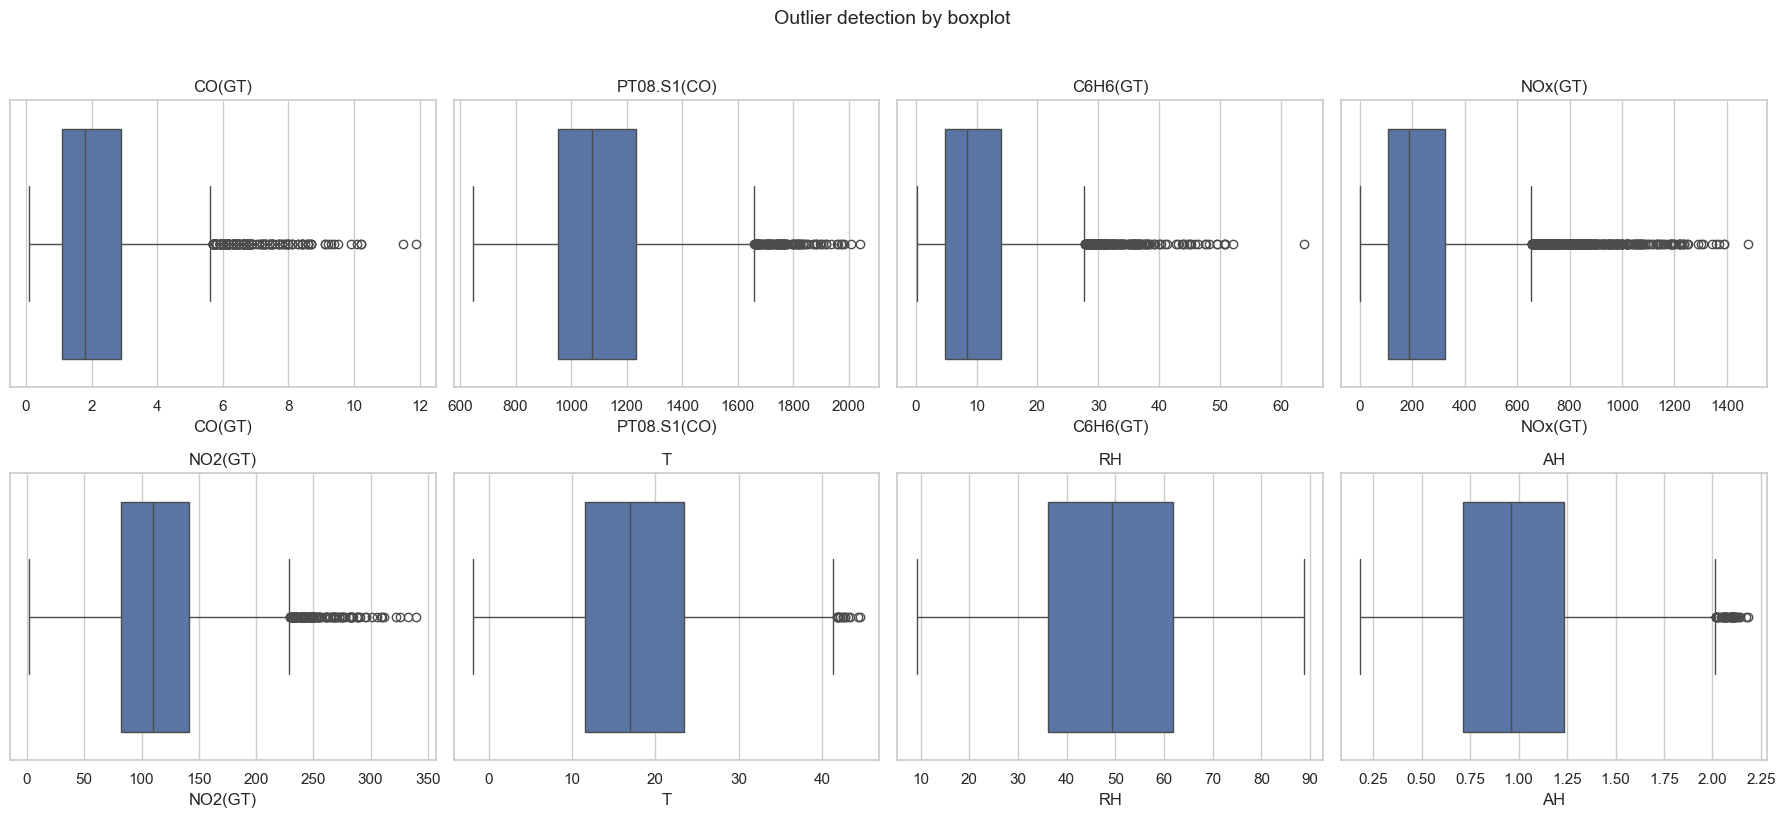

In [299]:
# Thống kê 1: Boxplot phát hiện outlier cho các biến chính
key_cols = ['CO(GT)', 'PT08.S1(CO)', 'C6H6(GT)', 'NOx(GT)', 'NO2(GT)', 'T', 'RH', 'AH']
key_cols = [c for c in key_cols if c in vis_df.columns]

n_cols = 4
n_rows = int(np.ceil(len(key_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
axes = np.array(axes).reshape(-1)

for i, col in enumerate(key_cols):
    sns.boxplot(x=vis_df[col], ax=axes[i], color='#4C72B0')
    axes[i].set_title(col)

for j in range(i + 1, len(axes)):
    axes[j].axis('off')

plt.suptitle('Outlier detection by boxplot', y=1.02, fontsize=14)
plt.tight_layout()
plt.show()


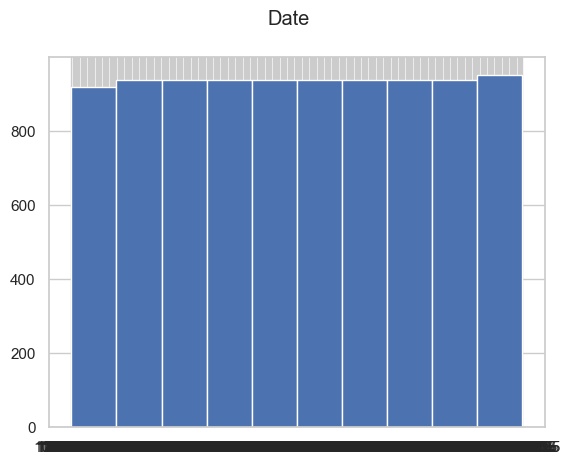

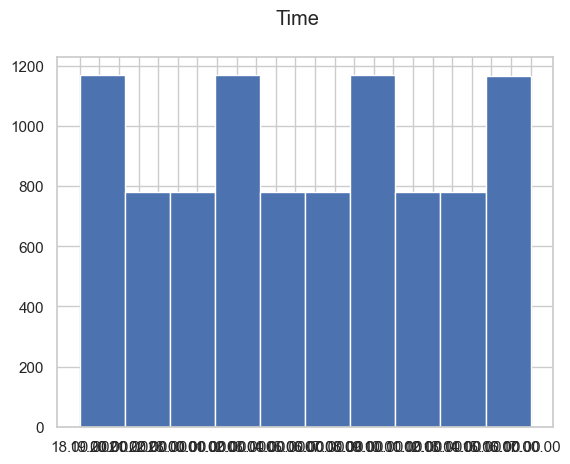

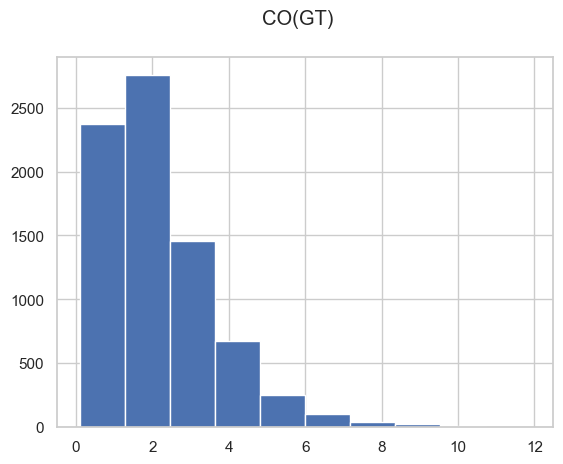

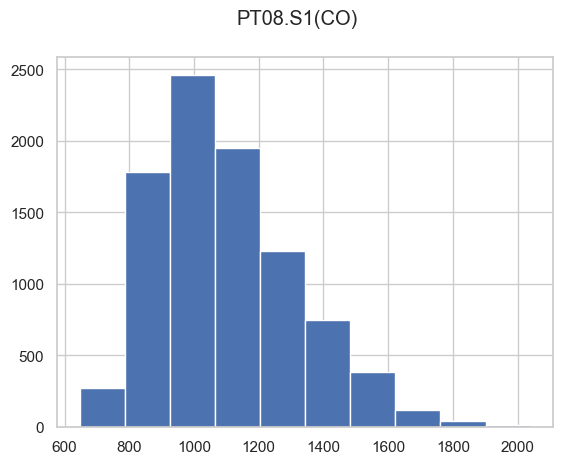

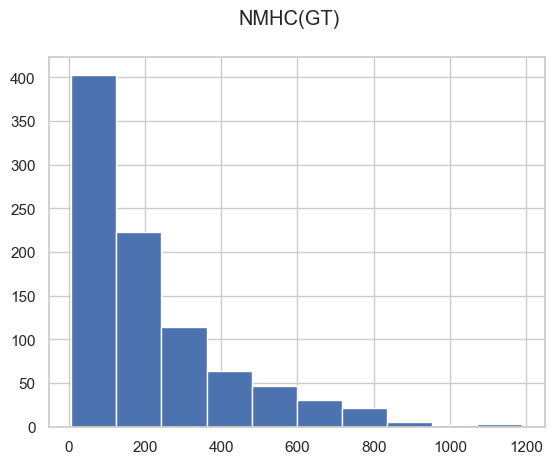

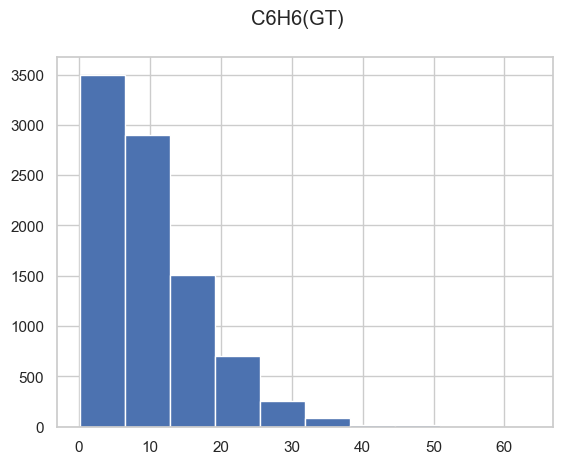

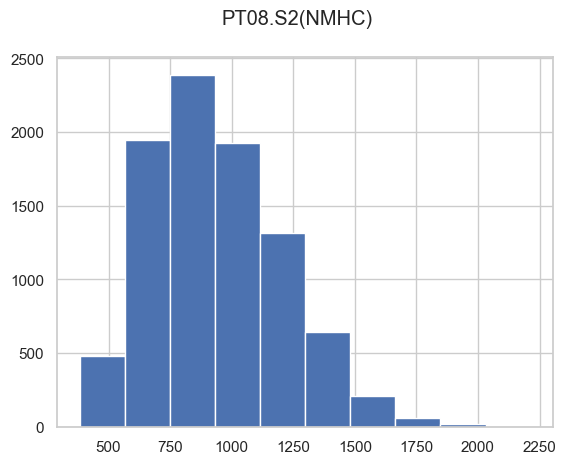

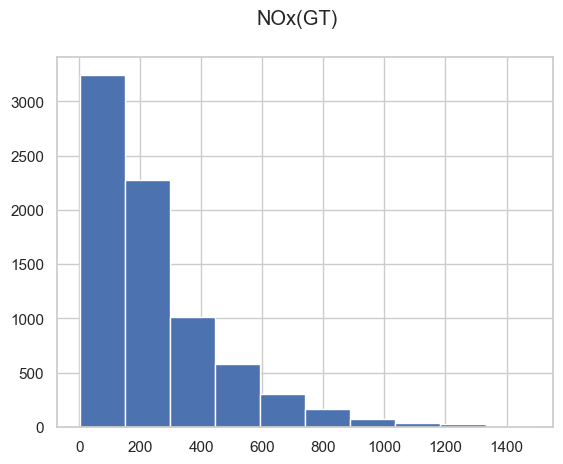

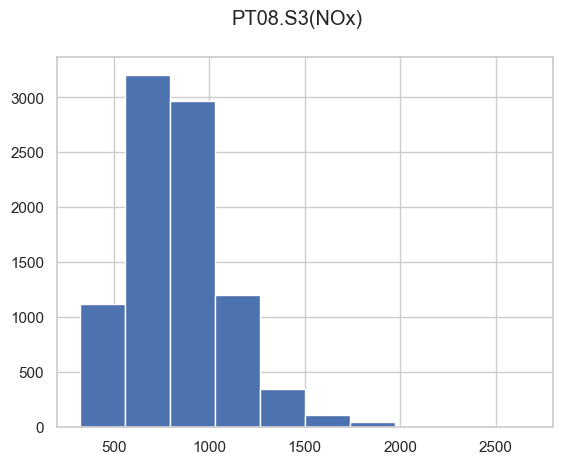

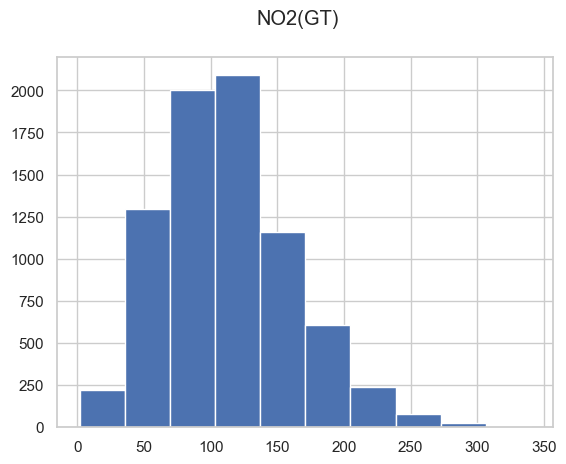

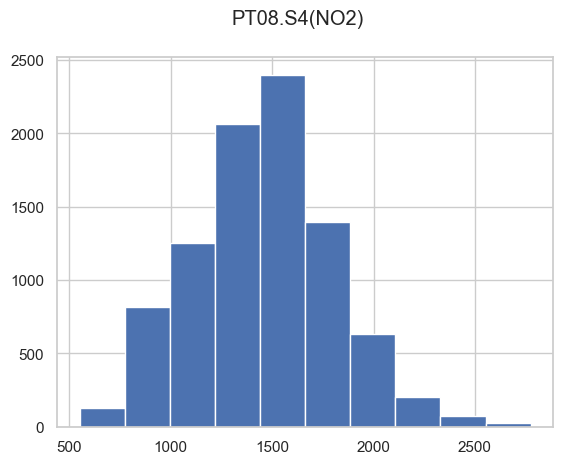

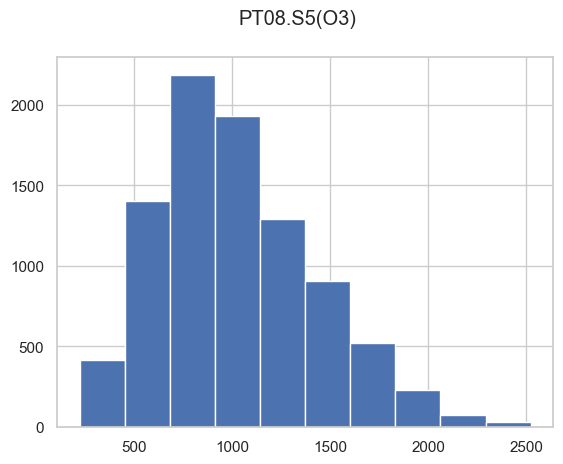

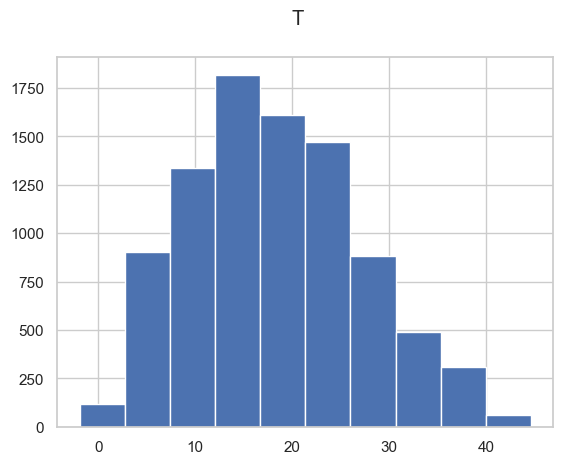

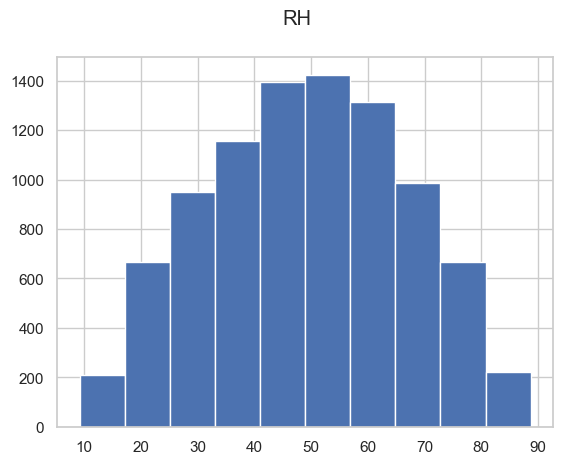

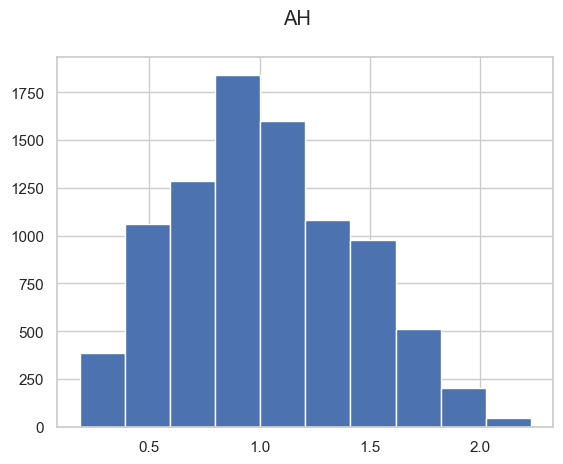

In [300]:
for col in df.columns:
  df[col].hist()
  plt.suptitle(col)
  plt.show()


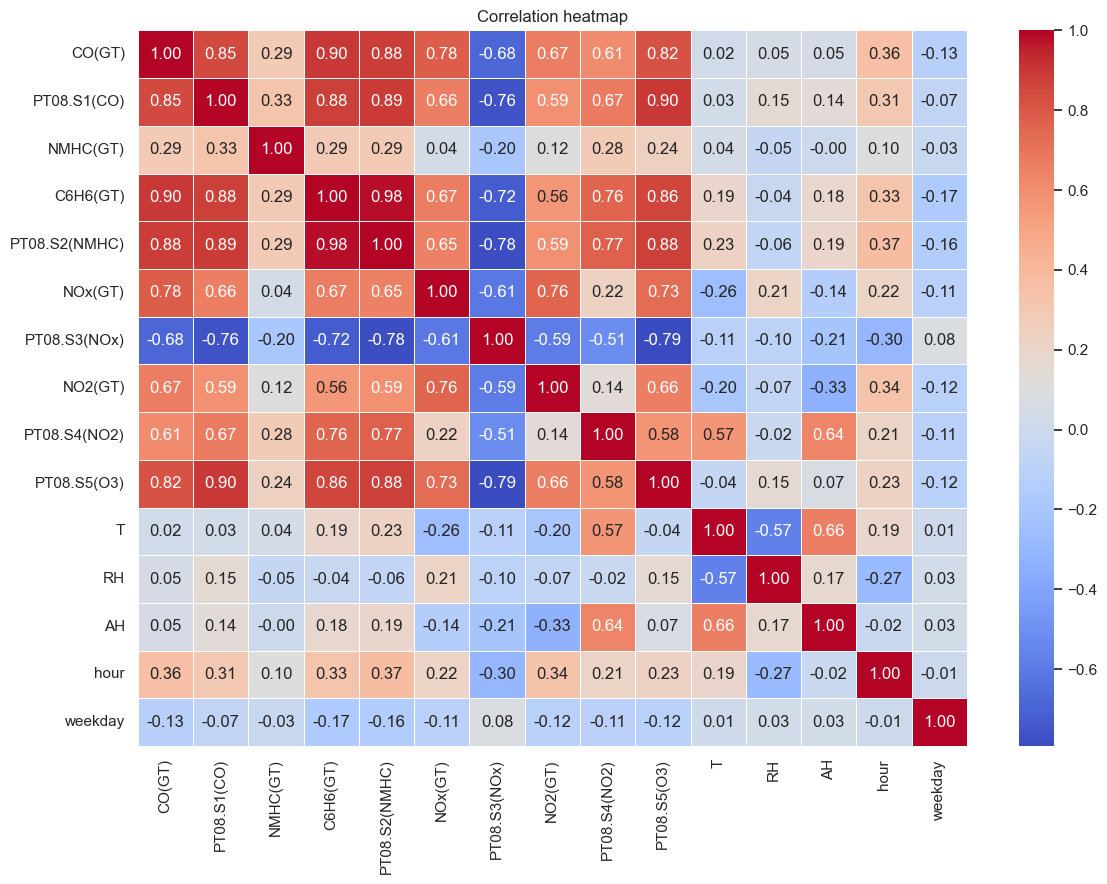

In [301]:
# Thống kê 2: Correlation heatmap giữa các biến số
num_df = vis_df.select_dtypes(include=[np.number]).copy()
corr = num_df.corr()

plt.figure(figsize=(12, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation heatmap')
plt.tight_layout()
plt.show()


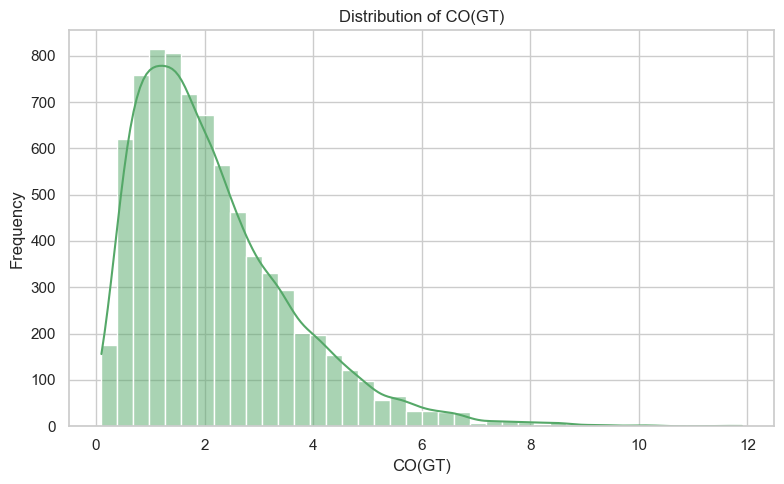

In [302]:
# Thống kê 3: Histogram + KDE của biến mục tiêu CO(GT)
plt.figure(figsize=(8, 5))
sns.histplot(vis_df['CO(GT)'], bins=40, kde=True, color='#55A868')
plt.title('Distribution of CO(GT)')
plt.xlabel('CO(GT)')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()


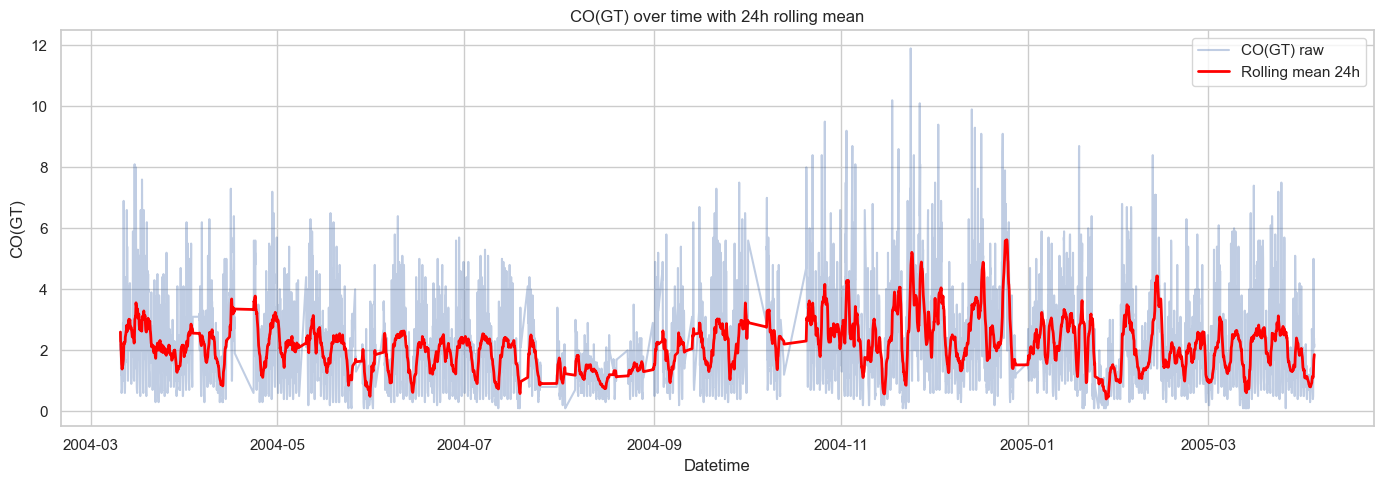

In [303]:
# Thống kê 4: Chuỗi thời gian CO(GT) + rolling mean 24 giờ
ts = vis_df[['Datetime', 'CO(GT)']].dropna().sort_values('Datetime').copy()
ts['CO_24h_mean'] = ts['CO(GT)'].rolling(window=24, min_periods=1).mean()

plt.figure(figsize=(14, 5))
plt.plot(ts['Datetime'], ts['CO(GT)'], alpha=0.35, label='CO(GT) raw')
plt.plot(ts['Datetime'], ts['CO_24h_mean'], color='red', linewidth=2, label='Rolling mean 24h')
plt.title('CO(GT) over time with 24h rolling mean')
plt.xlabel('Datetime')
plt.ylabel('CO(GT)')
plt.legend()
plt.tight_layout()
plt.show()


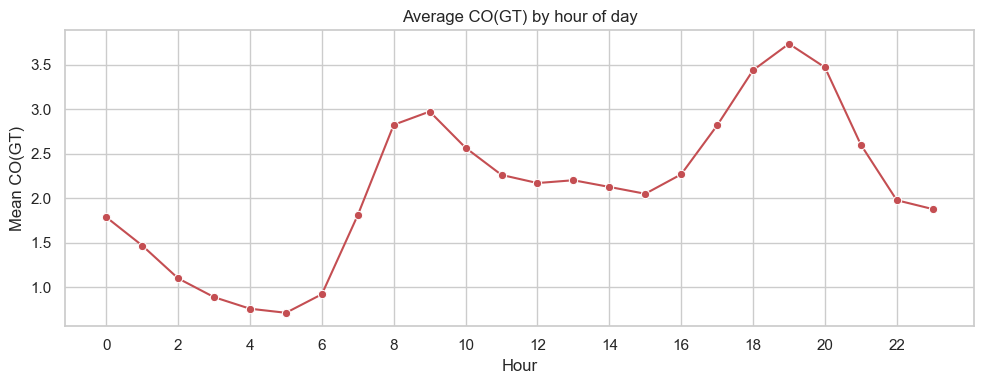

In [304]:
# Thống kê 5: CO(GT) trung bình theo giờ trong ngày
hourly = vis_df.groupby('hour', as_index=False)['CO(GT)'].mean()

plt.figure(figsize=(10, 4))
sns.lineplot(data=hourly, x='hour', y='CO(GT)', marker='o', color='#C44E52')
plt.title('Average CO(GT) by hour of day')
plt.xlabel('Hour')
plt.ylabel('Mean CO(GT)')
plt.xticks(range(0, 24, 2))
plt.tight_layout()
plt.show()


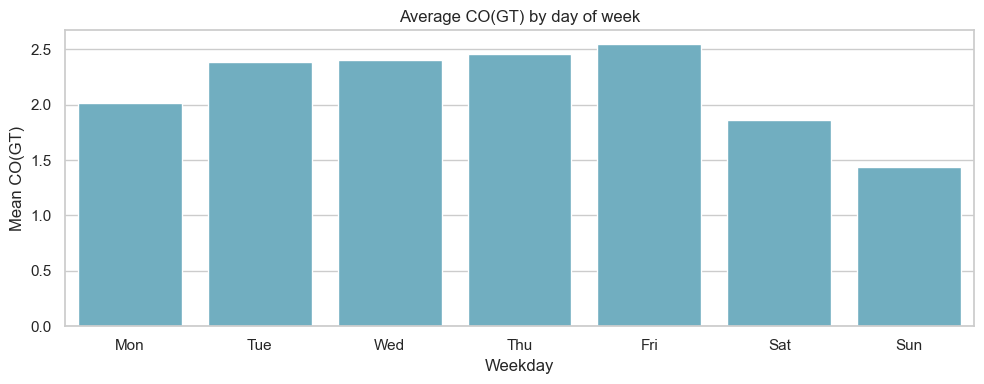

In [305]:
# Thong ke 6: CO(GT) trung binh theo thu trong tuan
weekday_order = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

if 'weekday_name' not in vis_df.columns:
    raise ValueError('Chua co cot weekday_name. Hay chay cell khoi phuc vis_df truoc.')

weekday_mean = (
    vis_df.groupby('weekday_name', as_index=False)['CO(GT)'].mean()
    .set_index('weekday_name')
    .reindex(weekday_order)
    .reset_index()
)

plt.figure(figsize=(10, 4))
sns.barplot(data=weekday_mean, x='weekday_name', y='CO(GT)', color='#64B5CD')
plt.title('Average CO(GT) by day of week')
plt.xlabel('Weekday')
plt.ylabel('Mean CO(GT)')
plt.tight_layout()
plt.show()


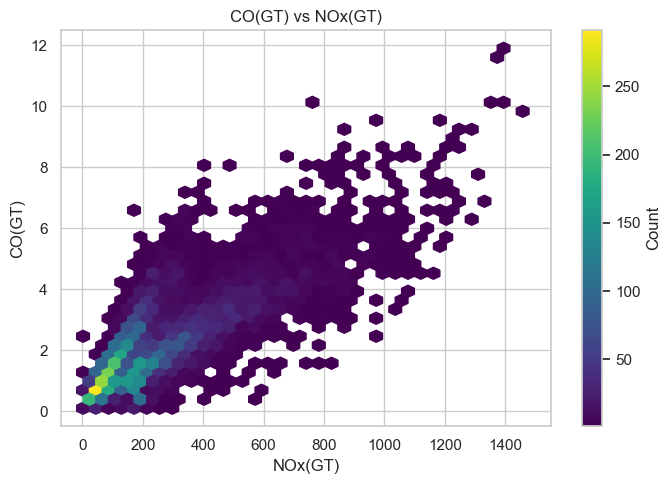

In [306]:
# Thống kê 7: Quan hệ CO(GT) với NOx(GT) bằng hexbin
x_col = 'NOx(GT)' if 'NOx(GT)' in vis_df.columns else 'PT08.S1(CO)'

plt.figure(figsize=(7, 5))
hb = plt.hexbin(vis_df[x_col], vis_df['CO(GT)'], gridsize=35, cmap='viridis', mincnt=1)
plt.colorbar(hb, label='Count')
plt.title(f'CO(GT) vs {x_col}')
plt.xlabel(x_col)
plt.ylabel('CO(GT)')
plt.tight_layout()
plt.show()


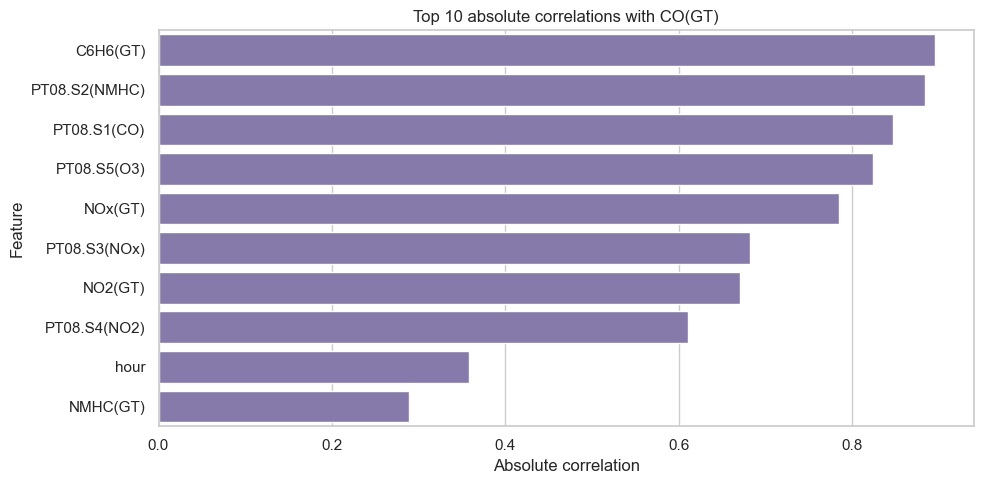

In [307]:
# Thống kê 8: Top biến tương quan mạnh nhất với CO(GT)
num_df_local = vis_df.select_dtypes(include=[np.number]).copy()
co_corr = num_df_local.corr(numeric_only=True)['CO(GT)'].drop('CO(GT)').abs().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x=co_corr.values, y=co_corr.index, color='#8172B2')
plt.title('Top 10 absolute correlations with CO(GT)')
plt.xlabel('Absolute correlation')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()


In [308]:
df4 = df3.copy()


## Chuyển thời gian sang biến số
Cell này ghép `Date` và `Time` thành một cột thời gian chuẩn, sau đó tách thành các đặc trưng như giờ, ngày, tháng và thứ trong tuần. Đồng thời tạo thêm `hour_sin` và `hour_cos` để mô tả tính chu kỳ của thời gian tốt hơn cho mô hình.

In [309]:
df4.head()


,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,10/03/2004,18.00.00,2.6,1360.0,150.0,11.9,1046.0,166.0,1056.0,113.0,1692.0,1268.0,13.6,48.9,0.7578
1,10/03/2004,19.00.00,2.0,1292.0,112.0,9.4,955.0,103.0,1174.0,92.0,1559.0,972.0,13.3,47.7,0.7255
2,10/03/2004,20.00.00,2.2,1402.0,88.0,9.0,939.0,131.0,1140.0,114.0,1555.0,1074.0,11.9,54.0,0.7502
3,10/03/2004,21.00.00,2.2,1376.0,80.0,9.2,948.0,172.0,1092.0,122.0,1584.0,1203.0,11.0,60.0,0.7867
4,10/03/2004,22.00.00,1.6,1272.0,51.0,6.5,836.0,131.0,1205.0,116.0,1490.0,1110.0,11.2,59.6,0.7888


In [310]:
# Khoi phuc cac feature thoi gian cho df4
df4['Time_fixed'] = df4['Time'].astype(str).str.replace('.', ':', regex=False)
df4['Datetime'] = pd.to_datetime(
    df4['Date'].astype(str) + ' ' + df4['Time_fixed'],
    format='%d/%m/%Y %H:%M:%S',
    errors='coerce'
)

df4 = (
    df4.dropna(subset=['Datetime'])
       .sort_values('Datetime')
       .reset_index(drop=True)
)

# Tao cac bien thoi gian co ban cho modeling
df4['hour'] = df4['Datetime'].dt.hour
df4['day'] = df4['Datetime'].dt.day
df4['month'] = df4['Datetime'].dt.month
df4['weekday'] = df4['Datetime'].dt.weekday

# Ma hoa chu ky gio
df4['hour_sin'] = np.sin(2 * np.pi * df4['hour'] / 24)
df4['hour_cos'] = np.cos(2 * np.pi * df4['hour'] / 24)

# Khong giu cot tho sau khi tao feature
df4.drop(columns=['Date', 'Time', 'Datetime', 'Time_fixed', 'PT08.S2(NMHC)', 'PT08.S5(O3)'], inplace=True)

print(df4[['hour', 'day', 'month', 'weekday', 'hour_sin', 'hour_cos']].head())


   hour  day  month  weekday  hour_sin      hour_cos
0    18   10      3        2 -1.000000 -1.836970e-16
1    19   10      3        2 -0.965926  2.588190e-01
2    20   10      3        2 -0.866025  5.000000e-01
3    21   10      3        2 -0.707107  7.071068e-01
4    22   10      3        2 -0.500000  8.660254e-01


In [311]:
df4.groupby('weekday')['CO(GT)'].mean()


weekday
0    2.016741
1    2.382267
2    2.400787
3    2.455505
4    2.543041
5    1.861077
6    1.438069
Name: CO(GT), dtype: float64

In [312]:
df4['is_weekend'] = df4['weekday'].isin([3,4, 2]).astype(int)


## Tạo đặc trưng cuối tuần
Biến `is_weekend` giúp mô hình phân biệt ngày thường và cuối tuần, vì nhịp độ hoạt động của không khí và lưu lượng giao thông có thể thay đổi theo lịch làm việc và sinh hoạt.

In [313]:
df4['is_rush_hour'] = df4['hour'].isin([7,8,9,17,18,19]).astype(int)
df4['temp_humidity'] = df4['T'] * df4['RH']
df4.drop(columns=[ 'hour'], inplace=True)


## Tạo đặc trưng giờ cao điểm và tương tác biến số
Cell này gắn nhãn giờ cao điểm bằng `is_rush_hour`, sau đó tạo các biến tương tác như `temp_humidity` và `NOx_NO2_ratio` để nắm bắt quan hệ phi tuyến giữa các yếu tố môi trường.

In [314]:
df4.info()


<class 'pandas.DataFrame'>
RangeIndex: 7674 entries, 0 to 7673
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   CO(GT)         7674 non-null   float64
 1   PT08.S1(CO)    7674 non-null   float64
 2   NMHC(GT)       7674 non-null   float64
 3   C6H6(GT)       7674 non-null   float64
 4   NOx(GT)        7674 non-null   float64
 5   PT08.S3(NOx)   7674 non-null   float64
 6   NO2(GT)        7674 non-null   float64
 7   PT08.S4(NO2)   7674 non-null   float64
 8   T              7674 non-null   float64
 9   RH             7674 non-null   float64
 10  AH             7674 non-null   float64
 11  day            7674 non-null   int32  
 12  month          7674 non-null   int32  
 13  weekday        7674 non-null   int32  
 14  hour_sin       7674 non-null   float64
 15  hour_cos       7674 non-null   float64
 16  is_weekend     7674 non-null   int64  
 17  is_rush_hour   7674 non-null   int64  
 18  temp_humidity  7674

## Kiểm tra cấu trúc dữ liệu sau feature engineering
Cell này dùng `info()` để xác nhận sau khi tạo các biến mới thì kiểu dữ liệu, số lượng cột và số lượng giá trị không thiếu vẫn hợp lệ.

In [315]:
df4.describe()


,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),T,RH,AH,day,month,weekday,hour_sin,hour_cos,is_weekend,is_rush_hour,temp_humidity
count,7674.000000,7674.000000,7674.000000,7674.000000,7674.000000,7674.000000,7674.000000,7674.000000,7674.000000,7674.000000,7674.000000,7674.000000,7674.000000,7674.000000,7674.000000,7.674000e+03,7674.000000,7674.000000,7674.000000
mean,2.152750,1109.050691,162.076753,10.199375,251.691165,825.547433,114.551082,1444.849361,17.732995,49.070394,0.988174,15.741986,6.072322,3.040526,-0.025968,-9.518872e-03,0.426114,0.256190,785.787538
std,1.453252,214.048885,73.259501,7.288206,210.022201,251.152318,46.930717,342.727887,8.671809,17.072230,0.391242,8.702230,3.520469,2.006389,0.703302,7.104446e-01,0.494543,0.436556,333.811302
min,0.100000,647.000000,7.000000,0.200000,2.000000,322.000000,2.000000,551.000000,-1.900000,9.200000,0.184700,1.000000,1.000000,0.000000,-1.000000,-1.000000e+00,0.000000,0.000000,-97.660000
25%,1.100000,953.000000,154.000000,4.800000,107.000000,657.000000,82.000000,1215.250000,11.500000,36.200000,0.714375,8.000000,3.000000,1.000000,-0.707107,-7.071068e-01,0.000000,0.000000,559.365000
50%,1.800000,1075.000000,154.000000,8.500000,188.000000,795.000000,110.000000,1447.000000,16.900000,49.300000,0.959700,16.000000,6.000000,3.000000,0.000000,-1.836970e-16,0.000000,0.000000,805.745000
75%,2.900000,1235.000000,154.000000,14.000000,326.000000,949.000000,141.000000,1659.000000,23.500000,61.800000,1.235200,23.000000,9.000000,5.000000,0.707107,7.071068e-01,1.000000,1.000000,989.572500
max,11.900000,2040.000000,1189.000000,63.700000,1479.000000,2683.000000,340.000000,2775.000000,44.600000,88.700000,2.180600,31.000000,12.000000,6.000000,1.000000,1.000000e+00,1.000000,1.000000,1747.300000


In [316]:
value_count(df4)


CO(GT)
1.0     305
1.4     279
1.6     275
1.5     273
1.1     262
       ... 
10.1      1
9.4       1
9.9       1
9.3       1
8.5       1
Name: count, Length: 96, dtype: int64
--------------------------------
PT08.S1(CO)
1075.0    345
973.0      26
1100.0     24
988.0      23
938.0      23
         ... 
1663.0      1
1726.0      1
1818.0      1
1619.0      1
1519.0      1
Name: count, Length: 1022, dtype: int64
--------------------------------
NMHC(GT)
154.0    6787
66.0       14
88.0        8
93.0        8
29.0        7
         ... 
344.0       1
265.0       1
365.0       1
642.0       1
501.0       1
Name: count, Length: 428, dtype: int64
--------------------------------
C6H6(GT)
8.5     368
3.6      74
2.8      66
3.8      64
2.5      61
       ... 
43.0      1
37.2      1
38.1      1
29.7      1
35.5      1
Name: count, Length: 393, dtype: int64
--------------------------------
NOx(GT)
188.0    433
89.0      37
65.0      35
95.0      33
180.0     33
        ... 
680.0      1
735.

## Tóm tắt tần suất giá trị của toàn bộ cột
Hàm `value_count(df4)` được dùng để rà lại phân phối từng cột sau khi tạo feature. Bước này giúp phát hiện cột có giá trị quá lệch hoặc ít thông tin, từ đó quyết định giữ hay bỏ trước khi modeling.

In [317]:
(df4['temp_humidity'] < 0).sum()


np.int64(12)

In [318]:
df4['temp_humidity'] = df4['temp_humidity'].clip(lower=0)


In [319]:
df4.info()


<class 'pandas.DataFrame'>
RangeIndex: 7674 entries, 0 to 7673
Data columns (total 19 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   CO(GT)         7674 non-null   float64
 1   PT08.S1(CO)    7674 non-null   float64
 2   NMHC(GT)       7674 non-null   float64
 3   C6H6(GT)       7674 non-null   float64
 4   NOx(GT)        7674 non-null   float64
 5   PT08.S3(NOx)   7674 non-null   float64
 6   NO2(GT)        7674 non-null   float64
 7   PT08.S4(NO2)   7674 non-null   float64
 8   T              7674 non-null   float64
 9   RH             7674 non-null   float64
 10  AH             7674 non-null   float64
 11  day            7674 non-null   int32  
 12  month          7674 non-null   int32  
 13  weekday        7674 non-null   int32  
 14  hour_sin       7674 non-null   float64
 15  hour_cos       7674 non-null   float64
 16  is_weekend     7674 non-null   int64  
 17  is_rush_hour   7674 non-null   int64  
 18  temp_humidity  7674

In [320]:
df4['weekend_rush'] = df4['is_weekend'] * df4['is_rush_hour']


In [321]:
df5 = df4.copy()


In [322]:
df5.info()


<class 'pandas.DataFrame'>
RangeIndex: 7674 entries, 0 to 7673
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   CO(GT)         7674 non-null   float64
 1   PT08.S1(CO)    7674 non-null   float64
 2   NMHC(GT)       7674 non-null   float64
 3   C6H6(GT)       7674 non-null   float64
 4   NOx(GT)        7674 non-null   float64
 5   PT08.S3(NOx)   7674 non-null   float64
 6   NO2(GT)        7674 non-null   float64
 7   PT08.S4(NO2)   7674 non-null   float64
 8   T              7674 non-null   float64
 9   RH             7674 non-null   float64
 10  AH             7674 non-null   float64
 11  day            7674 non-null   int32  
 12  month          7674 non-null   int32  
 13  weekday        7674 non-null   int32  
 14  hour_sin       7674 non-null   float64
 15  hour_cos       7674 non-null   float64
 16  is_weekend     7674 non-null   int64  
 17  is_rush_hour   7674 non-null   int64  
 18  temp_humidity  7674

In [323]:
# Check outliers in df5 with IQR rule
import pandas as pd
import numpy as np

numeric_cols = df5.select_dtypes(include=[np.number]).columns
rows = []

for col in numeric_cols:
    q1 = df5[col].quantile(0.25)
    q3 = df5[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outlier_mask = (df5[col] < lower) | (df5[col] > upper)
    outlier_count = int(outlier_mask.sum())
    outlier_rate = outlier_count / len(df5) * 100

    rows.append({
        "feature": col,
        "q1": q1,
        "q3": q3,
        "lower": lower,
        "upper": upper,
        "outlier_count": outlier_count,
        "outlier_rate_%": round(outlier_rate, 2)
    })

outlier_report = pd.DataFrame(rows).sort_values("outlier_rate_%", ascending=False)
outlier_report


,feature,q1,q3,lower,upper,outlier_count,outlier_rate_%
2,NMHC(GT),154.000000,154.000000,154.000000,154.000000,887,11.56
19,weekend_rush,0.000000,0.000000,0.000000,0.000000,844,11.00
4,NOx(GT),107.000000,326.000000,-221.500000,654.500000,464,6.05
5,PT08.S3(NOx),657.000000,949.000000,219.000000,1387.000000,226,2.95
0,CO(GT),1.100000,2.900000,-1.600000,5.600000,215,2.80
3,C6H6(GT),4.800000,14.000000,-9.000000,27.800000,212,2.76
6,NO2(GT),82.000000,141.000000,-6.500000,229.500000,145,1.89
1,PT08.S1(CO),953.000000,1235.000000,530.000000,1658.000000,119,1.55
7,PT08.S4(NO2),1215.250000,1659.000000,549.625000,2324.625000,80,1.04
10,AH,0.714375,1.235200,-0.066863,2.016438,46,0.60


In [324]:
# Winsorize selected continuous features in df5
df6 = df5.copy()

# Columns that should NOT be winsorized
exclude_cols = {'weekend_rush', 'is_weekend', 'is_rush_hour', 'day', 'month', 'weekday', 'hour_sin', 'hour_cos'}

# Pick columns with outliers from your report and exclude discrete/binary flags
cols_to_clip = outlier_report.loc[
(outlier_report['outlier_rate_%'] > 0) & (~outlier_report['feature'].isin(exclude_cols)),
'feature'
].tolist()

bounds = {}
for col in cols_to_clip:
    q1 = df6[col].quantile(0.25)
    q3 = df6[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    bounds[col] = (lower, upper)
    df6[col] = df6[col].clip(lower=lower, upper=upper)

# Quick check: outlier counts before vs after on processed columns
compare_rows = []
for col in cols_to_clip:
    lower, upper = bounds[col]
    before_cnt = int(((df5[col] < lower) | (df5[col] > upper)).sum())
    after_cnt = int(((df6[col] < lower) | (df6[col] > upper)).sum())
    compare_rows.append({
    'feature': col,
    'before_outliers': before_cnt,
    'after_outliers': after_cnt
    })

outlier_fix_report = pd.DataFrame(compare_rows).sort_values('before_outliers', ascending=False).reset_index(drop=True)
print('Processed columns:', cols_to_clip)
outlier_fix_report.head(15)

# If you want to continue modeling with cleaned data, uncomment the next line:
# df5 = df5_out.copy()


Processed columns: ['NMHC(GT)', 'NOx(GT)', 'PT08.S3(NOx)', 'CO(GT)', 'C6H6(GT)', 'NO2(GT)', 'PT08.S1(CO)', 'PT08.S4(NO2)', 'AH', 'T', 'temp_humidity']


,feature,before_outliers,after_outliers
0,NMHC(GT),887,0
1,NOx(GT),464,0
2,PT08.S3(NOx),226,0
3,CO(GT),215,0
4,C6H6(GT),212,0
5,NO2(GT),145,0
6,PT08.S1(CO),119,0
7,PT08.S4(NO2),80,0
8,AH,46,0
9,T,15,0


## Xử lý ngoại lai (winsorize) trên df5
Cell này xử lý ngoại lai bằng cách clip theo ngưỡng IQR cho các biến liên tục có outlier. Các biến nhị phân/cờ như `weekend_rush`, `is_weekend`, `is_rush_hour` sẽ được giữ nguyên.

In [325]:
# Check outliers in df5 with IQR rule
import pandas as pd
import numpy as np

numeric_cols = df6.select_dtypes(include=[np.number]).columns
rows = []

for col in numeric_cols:
    q1 = df6[col].quantile(0.25)
    q3 = df6[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outlier_mask = (df6[col] < lower) | (df6[col] > upper)
    outlier_count = int(outlier_mask.sum())
    outlier_rate = outlier_count / len(df6) * 100

    rows.append({
        "feature": col,
        "q1": q1,
        "q3": q3,
        "lower": lower,
        "upper": upper,
        "outlier_count": outlier_count,
        "outlier_rate_%": round(outlier_rate, 2)
    })

outlier_report = pd.DataFrame(rows).sort_values("outlier_rate_%", ascending=False)
outlier_report


,feature,q1,q3,lower,upper,outlier_count,outlier_rate_%
19,weekend_rush,0.000000,0.000000,0.000000,0.000000,844,11.0
1,PT08.S1(CO),953.000000,1235.000000,530.000000,1658.000000,0,0.0
18,temp_humidity,559.365000,989.572500,-85.946250,1634.883750,0,0.0
17,is_rush_hour,0.000000,1.000000,-1.500000,2.500000,0,0.0
16,is_weekend,0.000000,1.000000,-1.500000,2.500000,0,0.0
15,hour_cos,-0.707107,0.707107,-2.828427,2.828427,0,0.0
14,hour_sin,-0.707107,0.707107,-2.828427,2.828427,0,0.0
13,weekday,1.000000,5.000000,-5.000000,11.000000,0,0.0
12,month,3.000000,9.000000,-6.000000,18.000000,0,0.0
11,day,8.000000,23.000000,-14.500000,45.500000,0,0.0


In [326]:
df6.shape


(7674, 20)

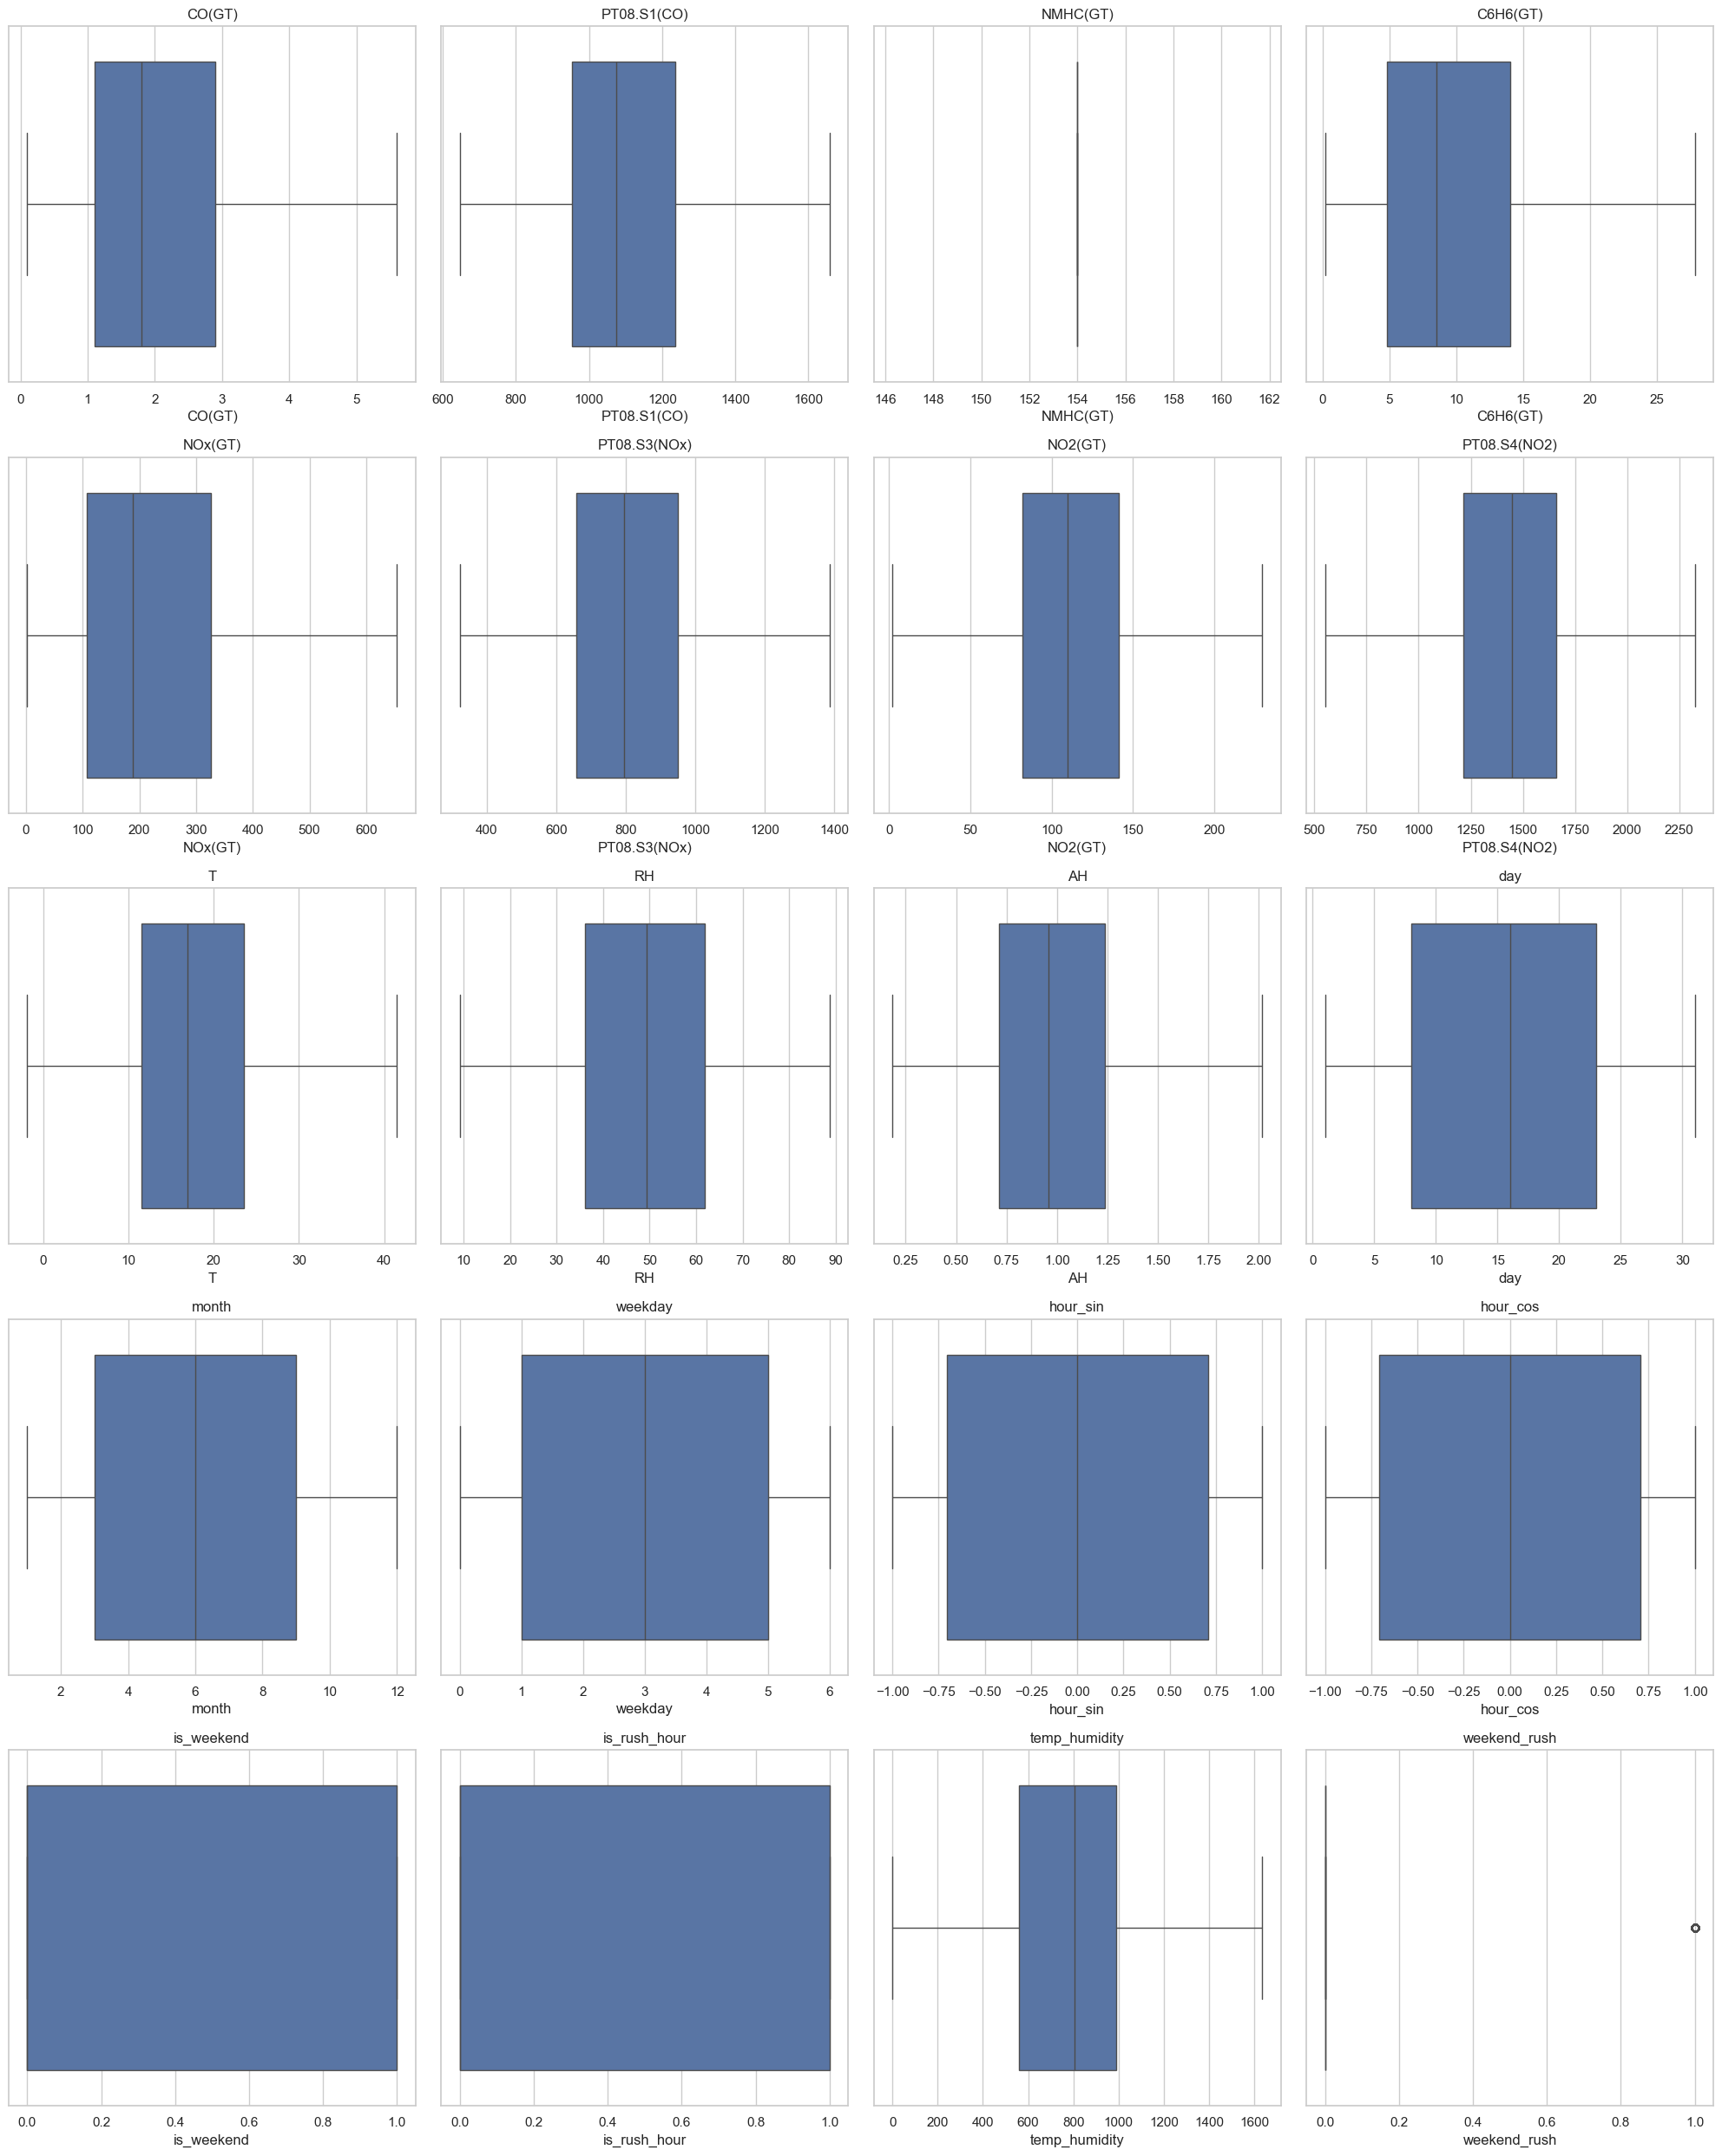

In [327]:
import math

n_cols = 4  # số cột hiển thị
n_rows = math.ceil(len(df6.columns) / n_cols)

plt.figure(figsize=(20, 5 * n_rows))

for i, col in enumerate(df6.columns, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(x=df6[col])
    plt.title(col)

plt.tight_layout()
plt.show()


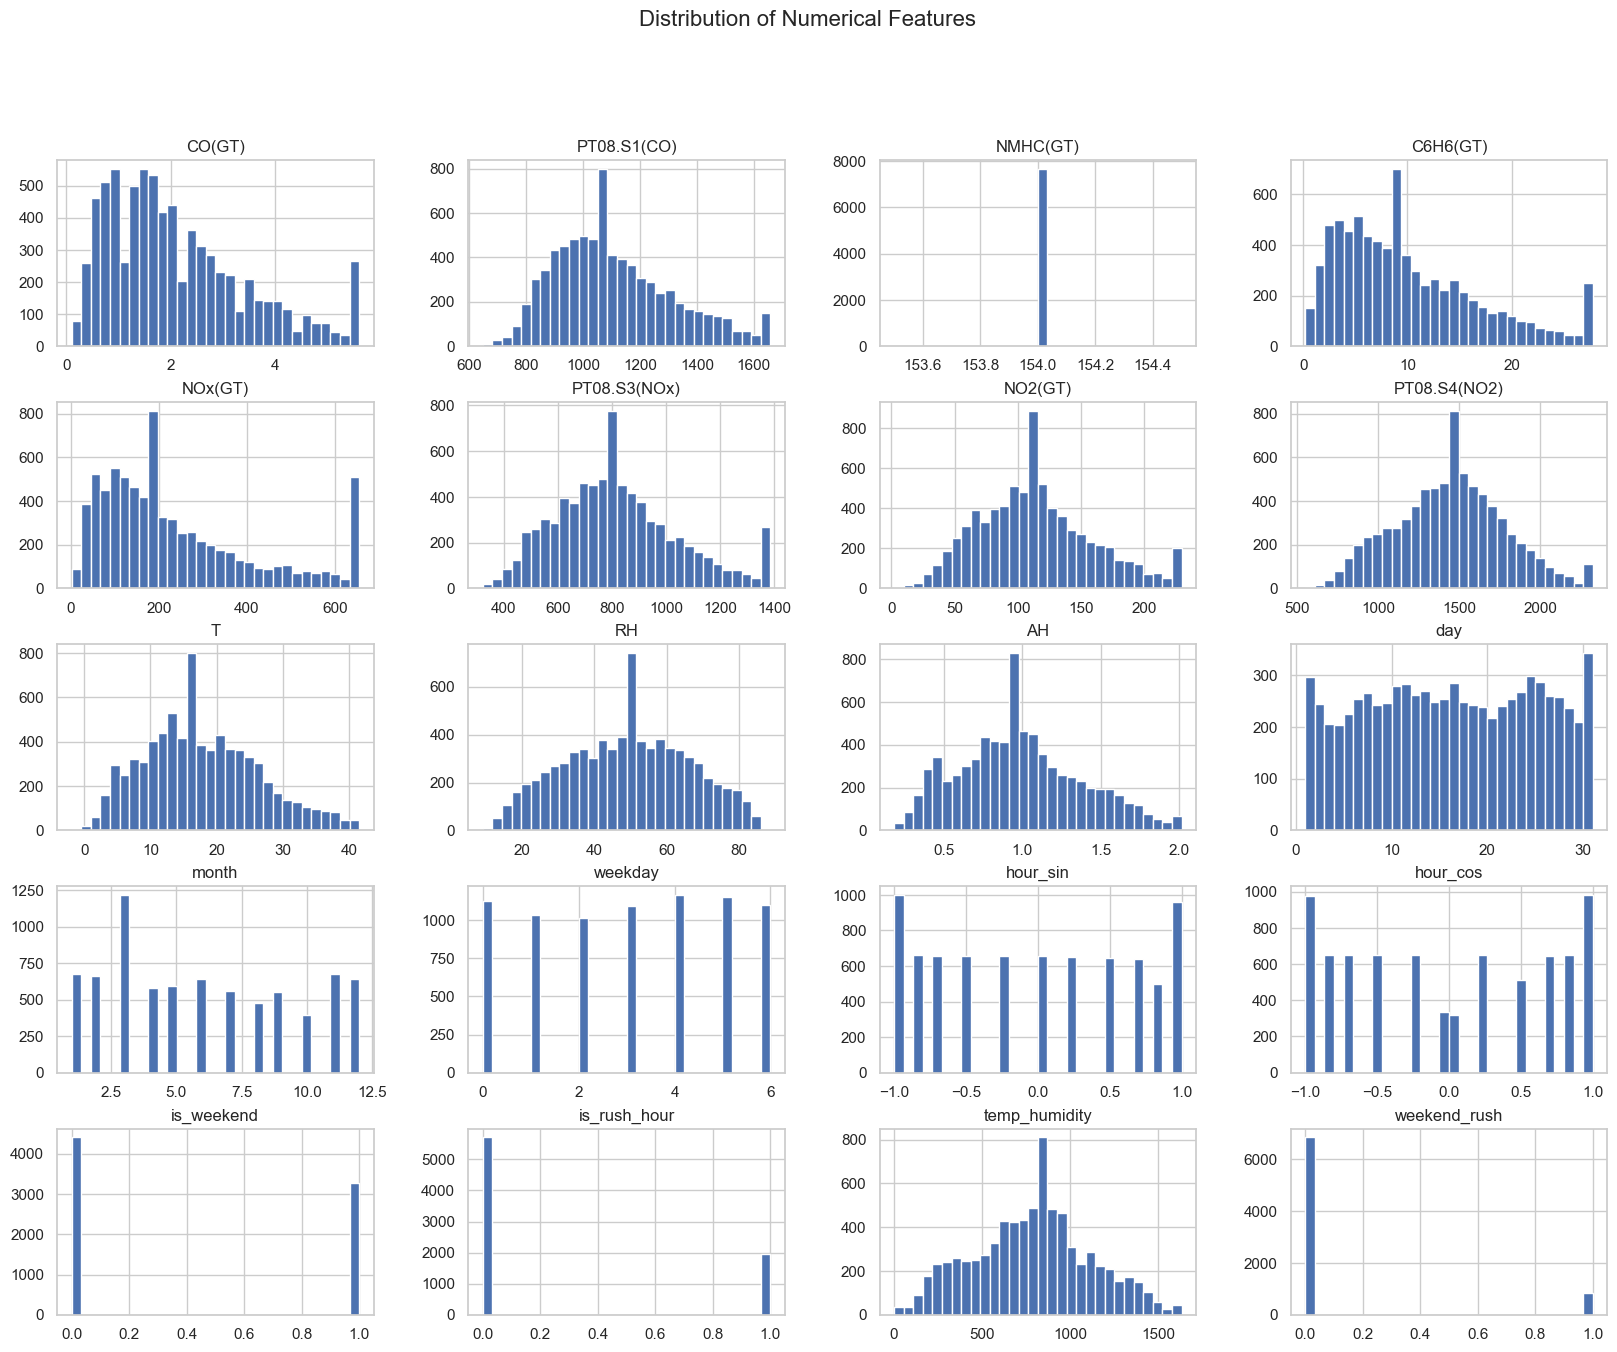

In [328]:
df6.hist(figsize=(20, 15), bins=30)
plt.suptitle("Distribution of Numerical Features", fontsize=16)
plt.show()


In [329]:
df6.info()


<class 'pandas.DataFrame'>
RangeIndex: 7674 entries, 0 to 7673
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   CO(GT)         7674 non-null   float64
 1   PT08.S1(CO)    7674 non-null   float64
 2   NMHC(GT)       7674 non-null   float64
 3   C6H6(GT)       7674 non-null   float64
 4   NOx(GT)        7674 non-null   float64
 5   PT08.S3(NOx)   7674 non-null   float64
 6   NO2(GT)        7674 non-null   float64
 7   PT08.S4(NO2)   7674 non-null   float64
 8   T              7674 non-null   float64
 9   RH             7674 non-null   float64
 10  AH             7674 non-null   float64
 11  day            7674 non-null   int32  
 12  month          7674 non-null   int32  
 13  weekday        7674 non-null   int32  
 14  hour_sin       7674 non-null   float64
 15  hour_cos       7674 non-null   float64
 16  is_weekend     7674 non-null   int64  
 17  is_rush_hour   7674 non-null   int64  
 18  temp_humidity  7674

In [330]:
# Final checklist before train/test split (using df6)
check = {}

check['shape'] = df6.shape
check['duplicate_rows'] = int(df6.duplicated().sum())
check['nan_total'] = int(df6.isna().sum().sum())
check['inf_total'] = int(np.isinf(df6.select_dtypes(include=[np.number])).sum().sum())

obj_cols = df6.select_dtypes(include=['object']).columns.tolist()
check['object_columns'] = obj_cols

target_col = 'CO(GT)'
check['target_exists'] = target_col in df6.columns
check['target_nan'] = int(df6[target_col].isna().sum()) if target_col in df6.columns else None

print('=== FINAL PRE-SPLIT CHECK (df6) ===')
for k, v in check.items():
    print(f'{k}: {v}')

ready = (
    check['nan_total'] == 0
    and check['inf_total'] == 0
    and check['duplicate_rows'] == 0
    and len(check['object_columns']) == 0
    and check['target_exists']
    and check['target_nan'] == 0
)

print('\nSplit-ready:', ready)
if not ready:
    print('Need to fix the above issues before split.')
else:
    print('df6 is ready for train/test split.')


=== FINAL PRE-SPLIT CHECK (df6) ===
shape: (7674, 20)
duplicate_rows: 0
nan_total: 0
inf_total: 0
object_columns: []
target_exists: True
target_nan: 0

Split-ready: True
df6 is ready for train/test split.


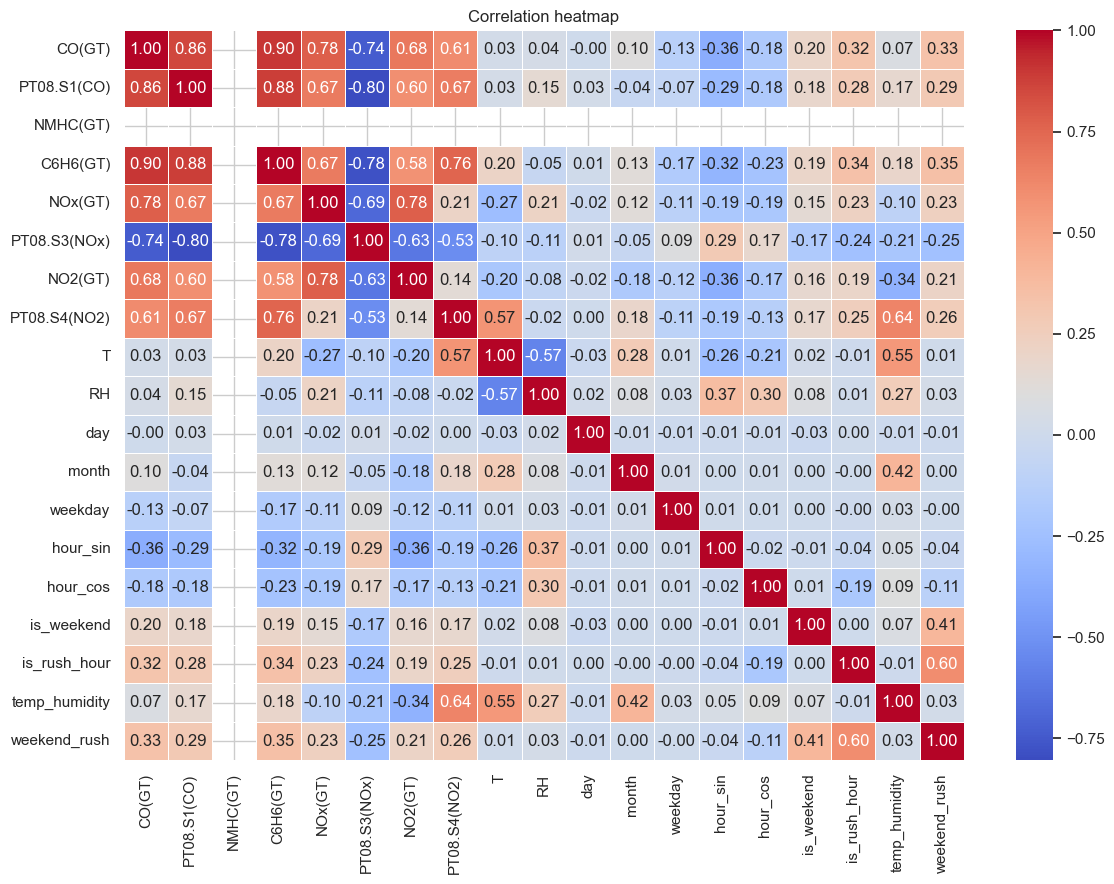

In [331]:
df6 = df6.drop(columns=['AH'])

# Thống kê 2: Correlation heatmap giữa các biến số
num_df = df6.select_dtypes(include=[np.number]).copy()
corr = num_df.corr()

plt.figure(figsize=(12, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation heatmap')
plt.tight_layout()
plt.show()


In [332]:
df6.head(10)


,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),T,RH,day,month,weekday,hour_sin,hour_cos,is_weekend,is_rush_hour,temp_humidity,weekend_rush
0,2.6,1360.0,154.0,11.9,166.0,1056.0,113.0,1692.0,13.6,48.9,10,3,2,-1.000000,-1.836970e-16,1,1,665.04,1
1,2.0,1292.0,154.0,9.4,103.0,1174.0,92.0,1559.0,13.3,47.7,10,3,2,-0.965926,2.588190e-01,1,1,634.41,1
2,2.2,1402.0,154.0,9.0,131.0,1140.0,114.0,1555.0,11.9,54.0,10,3,2,-0.866025,5.000000e-01,1,0,642.60,0
3,2.2,1376.0,154.0,9.2,172.0,1092.0,122.0,1584.0,11.0,60.0,10,3,2,-0.707107,7.071068e-01,1,0,660.00,0
4,1.6,1272.0,154.0,6.5,131.0,1205.0,116.0,1490.0,11.2,59.6,10,3,2,-0.500000,8.660254e-01,1,0,667.52,0
5,1.2,1197.0,154.0,4.7,89.0,1337.0,96.0,1393.0,11.2,59.2,10,3,2,-0.258819,9.659258e-01,1,0,663.04,0
6,1.2,1185.0,154.0,3.6,62.0,1387.0,77.0,1333.0,11.3,56.8,11,3,3,0.000000,1.000000e+00,1,0,641.84,0
7,1.0,1136.0,154.0,3.3,62.0,1387.0,76.0,1333.0,10.7,60.0,11,3,3,0.258819,9.659258e-01,1,0,642.00,0
8,0.9,1094.0,154.0,2.3,45.0,1387.0,60.0,1276.0,10.7,59.7,11,3,3,0.500000,8.660254e-01,1,0,638.79,0
9,0.6,1010.0,154.0,1.7,188.0,1387.0,110.0,1235.0,10.3,60.2,11,3,3,0.707107,7.071068e-01,1,0,620.06,0


In [333]:
# 2.3 - Step 1: Time-based split (80/20)

df_model = df6.copy()
target_col = 'CO(GT)'

if target_col not in df_model.columns:
    raise ValueError(f'Missing target column: {target_col}')

split_idx = int(len(df_model) * 0.8)
train_df = df_model.iloc[:split_idx].copy()
test_df = df_model.iloc[split_idx:].copy()

X_train = train_df.drop(columns=[target_col])
y_train = train_df[target_col]
X_test = test_df.drop(columns=[target_col])
y_test = test_df[target_col]

print('Train shape:', X_train.shape, y_train.shape)
print('Test shape :', X_test.shape, y_test.shape)


Train shape: (6139, 18) (6139,)
Test shape : (1535, 18) (1535,)


In [334]:
df6.head()


,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),T,RH,day,month,weekday,hour_sin,hour_cos,is_weekend,is_rush_hour,temp_humidity,weekend_rush
0,2.6,1360.0,154.0,11.9,166.0,1056.0,113.0,1692.0,13.6,48.9,10,3,2,-1.000000,-1.836970e-16,1,1,665.04,1
1,2.0,1292.0,154.0,9.4,103.0,1174.0,92.0,1559.0,13.3,47.7,10,3,2,-0.965926,2.588190e-01,1,1,634.41,1
2,2.2,1402.0,154.0,9.0,131.0,1140.0,114.0,1555.0,11.9,54.0,10,3,2,-0.866025,5.000000e-01,1,0,642.60,0
3,2.2,1376.0,154.0,9.2,172.0,1092.0,122.0,1584.0,11.0,60.0,10,3,2,-0.707107,7.071068e-01,1,0,660.00,0
4,1.6,1272.0,154.0,6.5,131.0,1205.0,116.0,1490.0,11.2,59.6,10,3,2,-0.500000,8.660254e-01,1,0,667.52,0


In [335]:
# 2.3 - Step 2: Standardization (fit on train only)
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Keep DataFrame version for easier debugging/inspection
X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print('Scaled train:', X_train_scaled.shape)
print('Scaled test :', X_test_scaled.shape)


Scaled train: (6139, 18)
Scaled test : (1535, 18)


In [336]:
print(X_train_scaled_df)


      PT08.S1(CO)  NMHC(GT)  C6H6(GT)   NOx(GT)  PT08.S3(NOx)   NO2(GT)  \
0        1.183596       0.0  0.196065 -0.349664      0.967811  0.151998   
1        0.863840       0.0 -0.170421 -0.708672      1.480147 -0.354234   
2        1.381093       0.0 -0.229059 -0.549113      1.332525  0.176105   
3        1.258833       0.0 -0.199740 -0.315473      1.124117  0.368955   
4        0.769794       0.0 -0.595546 -0.549113      1.614744  0.224317   
...           ...       ...       ...       ...           ...       ...   
6134    -1.482608       0.0 -1.431136 -0.896723      2.053269 -1.125635   
6135    -1.496714       0.0 -1.460455 -0.224297      2.357197  0.079680   
6136    -1.562547       0.0 -1.475115 -1.084775      2.404957 -1.752398   
6137    -1.609570       0.0 -1.475115 -1.107569      2.404957 -1.824717   
6138    -1.571951       0.0 -1.460455 -1.050584      2.404957 -1.680079   

      PT08.S4(NO2)         T        RH       day     month   weekday  \
0         0.560380 -0.69567

In [337]:
# 2.3 - Step 3.0: Ham danh gia chung cho bai toan hoi quy
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.neural_network import MLPRegressor

results = []
trained_models = {}
y_pred_store = {}

def regression_metrics(y_true, y_pred, eps=1e-8):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)

    # "Accuracy-like" metric cho regression: ti le du doan sai so tuong doi <= 20%
    rel_err = np.abs(y_true - y_pred) / np.maximum(np.abs(y_true), eps)
    acc_20pct = (rel_err <= 0.20).mean() * 100

    return mae, mse, rmse, r2, acc_20pct

print('Ready: metric helper initialized.')


Ready: metric helper initialized.


In [338]:
# 2.3 - Step 3.1: LinearRegression (scaled)
lin_model = LinearRegression()
lin_model.fit(X_train_scaled, y_train)
lin_pred = lin_model.predict(X_test_scaled)

mae, mse, rmse, r2, acc_20pct = regression_metrics(y_test.values, lin_pred)

results.append({
    'model': 'LinearRegression',
    'MAE': mae,
    'MSE': mse,
    'RMSE': rmse,
    'R2': r2,
    'ACC@20%': acc_20pct
})
trained_models['LinearRegression'] = lin_model
y_pred_store['LinearRegression'] = lin_pred


pd.DataFrame(results).sort_values('RMSE').reset_index(drop=True)


,model,MAE,MSE,RMSE,R2,ACC@20%
0,LinearRegression,0.365452,0.269632,0.519261,0.836423,60.130293


In [339]:
# 2.3 - Step 3.2: RandomForest (raw)
rf_model = RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

mae, mse, rmse, r2, acc_20pct = regression_metrics(y_test.values, rf_pred)

results.append({
    'model': 'RandomForest',
    'MAE': mae,
    'MSE': mse,
    'RMSE': rmse,
    'R2': r2,
    'ACC@20%': acc_20pct
})
trained_models['RandomForest'] = rf_model
y_pred_store['RandomForest'] = rf_pred

y_compare_rf = pd.DataFrame({
    'y_label': y_test.values,
    'y_pred': rf_pred
}, index=y_test.index)

pd.DataFrame(results).sort_values('RMSE').reset_index(drop=True)


,model,MAE,MSE,RMSE,R2,ACC@20%
0,RandomForest,0.337595,0.254566,0.504545,0.845563,67.947883
1,LinearRegression,0.365452,0.269632,0.519261,0.836423,60.130293


In [340]:
# 2.3 - Step 3.3: XGBoost (raw)
xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(X_train, y_train)
xgb_pred = xgb_model.predict(X_test)

mae, mse, rmse, r2, acc_20pct = regression_metrics(y_test.values, xgb_pred)

results.append({
    'model': 'XGBoost',
    'MAE': mae,
    'MSE': mse,
    'RMSE': rmse,
    'R2': r2,
    'ACC@20%': acc_20pct
})
trained_models['XGBoost'] = xgb_model
y_pred_store['XGBoost'] = xgb_pred

y_compare_xgb = pd.DataFrame({
    'y_label': y_test.values,
    'y_pred': xgb_pred
}, index=y_test.index)
pd.DataFrame(results).sort_values('RMSE').reset_index(drop=True)


,model,MAE,MSE,RMSE,R2,ACC@20%
0,RandomForest,0.337595,0.254566,0.504545,0.845563,67.947883
1,LinearRegression,0.365452,0.269632,0.519261,0.836423,60.130293
2,XGBoost,0.373001,0.288487,0.537110,0.824985,59.934853


In [341]:
# 2.3 - Step 3.4: MLPRegressor (scaled)
mlp_model = MLPRegressor(
    hidden_layer_sizes=(128, 64),
    activation='relu',
    solver='adam',
    learning_rate_init=1e-3,
    max_iter=500,
    early_stopping=True,
    validation_fraction=0.2,
    n_iter_no_change=20,
    random_state=42
)

mlp_model.fit(X_train_scaled, y_train)
mlp_pred = mlp_model.predict(X_test_scaled)

mae, mse, rmse, r2, acc_20pct = regression_metrics(y_test.values, mlp_pred)

results.append({
    'model': 'MLPRegressor',
    'MAE': mae,
    'MSE': mse,
    'RMSE': rmse,
    'R2': r2,
    'ACC@20%': acc_20pct
})
trained_models['MLPRegressor'] = mlp_model
y_pred_store['MLPRegressor'] = mlp_pred

y_compare_mlp = pd.DataFrame({
    'y_label': y_test.values,
    'y_pred': mlp_pred
}, index=y_test.index)

pd.DataFrame(results).sort_values('RMSE').reset_index(drop=True)


,model,MAE,MSE,RMSE,R2,ACC@20%
0,RandomForest,0.337595,0.254566,0.504545,0.845563,67.947883
1,LinearRegression,0.365452,0.269632,0.519261,0.836423,60.130293
2,XGBoost,0.373001,0.288487,0.537110,0.824985,59.934853
3,MLPRegressor,0.524036,0.484964,0.696394,0.705788,41.954397


## 2.4 Truc quan hoa don gian (moi y 1 cell)
Phan nay chi giu cac bieu do can thiet, code ngan de de doc va de dua vao bao cao.

In [342]:
# Cell 1: Bang metric test (day du)
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

eps = 1e-8
rows = []
for name, pred in y_pred_store.items():
    rel_err = np.abs(y_test.values - pred) / np.maximum(np.abs(y_test.values), eps)
    rows.append({
        'model': name,
        'MAE': mean_absolute_error(y_test, pred),
        'MSE': mean_squared_error(y_test, pred),
        'RMSE': np.sqrt(mean_squared_error(y_test, pred)),
        'R2': r2_score(y_test, pred),
        'ACC@20%': (rel_err <= 0.20).mean() * 100
    })

metrics_simple = pd.DataFrame(rows).sort_values('RMSE').reset_index(drop=True)
display(metrics_simple.round(4))


,model,MAE,MSE,RMSE,R2,ACC@20%
0,RandomForest,0.3376,0.2546,0.5045,0.8456,67.9479
1,LinearRegression,0.3655,0.2696,0.5193,0.8364,60.1303
2,XGBoost,0.3730,0.2885,0.5371,0.8250,59.9349
3,MLPRegressor,0.5240,0.4850,0.6964,0.7058,41.9544


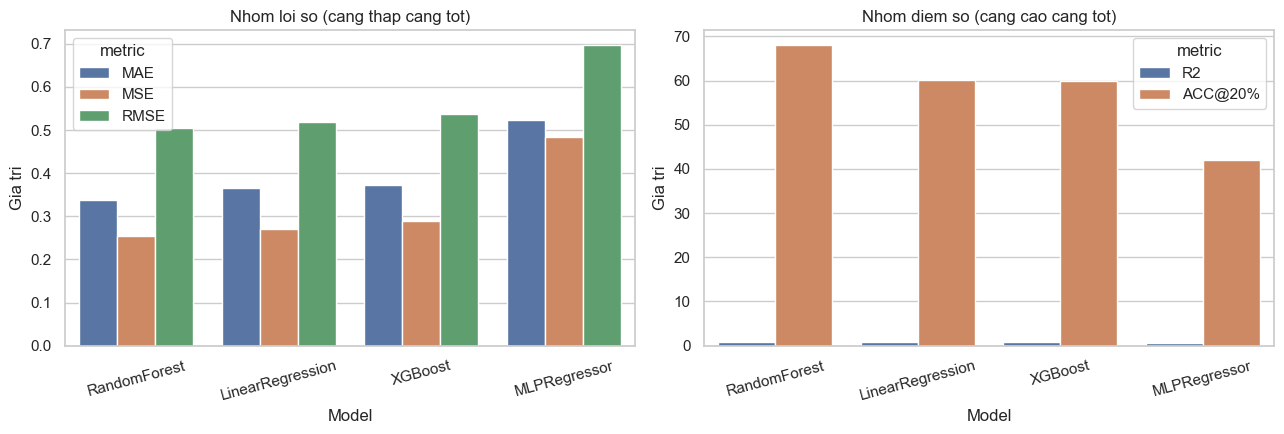

In [343]:
# Cell 2: Hien thi tat ca do do (gon va dep)
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))

err_cols = ['MAE', 'MSE', 'RMSE']
score_cols = ['R2', 'ACC@20%']

err_df = metrics_simple.melt(id_vars='model', value_vars=err_cols, var_name='metric', value_name='value')
score_df = metrics_simple.melt(id_vars='model', value_vars=score_cols, var_name='metric', value_name='value')

sns.barplot(data=err_df, x='model', y='value', hue='metric', ax=ax[0])
ax[0].set_title('Nhom loi so (cang thap cang tot)')
ax[0].set_xlabel('Model')
ax[0].set_ylabel('Gia tri')
ax[0].tick_params(axis='x', rotation=15)

sns.barplot(data=score_df, x='model', y='value', hue='metric', ax=ax[1])
ax[1].set_title('Nhom diem so (cang cao cang tot)')
ax[1].set_xlabel('Model')
ax[1].set_ylabel('Gia tri')
ax[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()


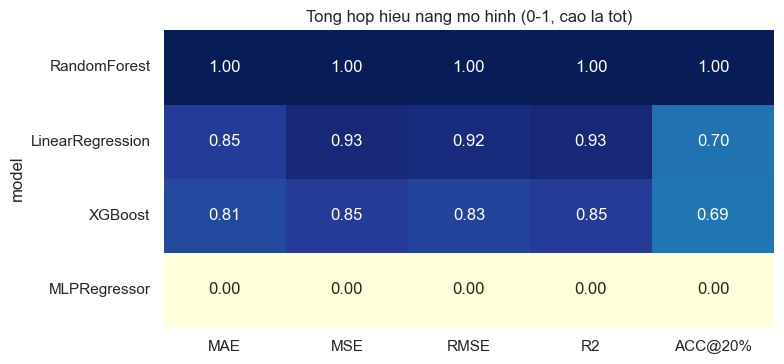

In [344]:
# Cell 2b: Heatmap tong hop cac do do (normalized)
heat_df = metrics_simple.set_index('model')[['MAE', 'MSE', 'RMSE', 'R2', 'ACC@20%']].copy()

norm_df = heat_df.copy()
for c in ['MAE', 'MSE', 'RMSE']:
    norm_df[c] = 1 - (norm_df[c] - norm_df[c].min()) / (norm_df[c].max() - norm_df[c].min() + 1e-12)
for c in ['R2', 'ACC@20%']:
    norm_df[c] = (norm_df[c] - norm_df[c].min()) / (norm_df[c].max() - norm_df[c].min() + 1e-12)

plt.figure(figsize=(8, 3.8))
sns.heatmap(norm_df, annot=True, cmap='YlGnBu', fmt='.2f', cbar=False)
plt.title('Tong hop hieu nang mo hinh (0-1, cao la tot)')
plt.tight_layout()
plt.show()


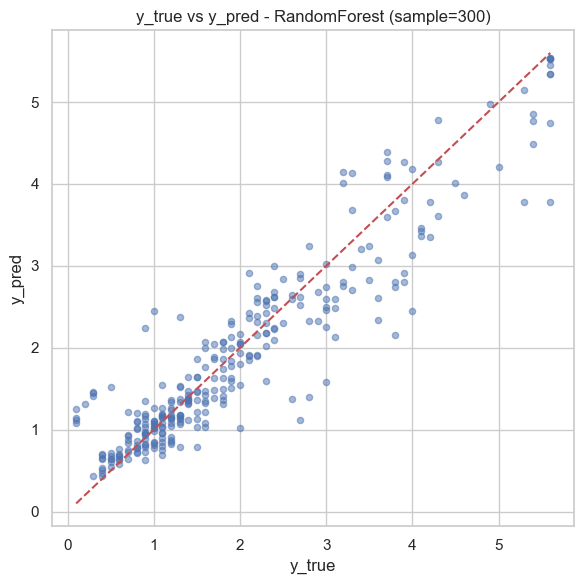

In [345]:
# Cell 3: Scatter y_true vs y_pred cho model tot nhat (lay 300 diem)
best_model = metrics_simple.loc[0, 'model']
best_pred = y_pred_store[best_model]

sample_n = min(300, len(y_test))
idx = np.linspace(0, len(y_test) - 1, sample_n, dtype=int)
y_true_s = y_test.values[idx]
y_pred_s = best_pred[idx]

plt.figure(figsize=(6, 6))
plt.scatter(y_true_s, y_pred_s, alpha=0.5, s=20)
mn = min(y_true_s.min(), y_pred_s.min())
mx = max(y_true_s.max(), y_pred_s.max())
plt.plot([mn, mx], [mn, mx], 'r--', linewidth=1.5)
plt.title(f'y_true vs y_pred - {best_model} (sample={sample_n})')
plt.xlabel('y_true')
plt.ylabel('y_pred')
plt.tight_layout()
plt.show()


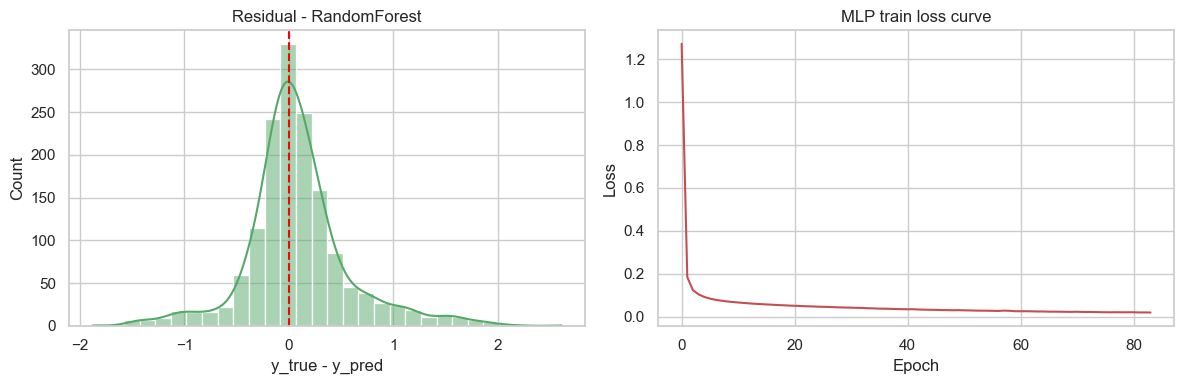

In [346]:
# Cell 4: Residual + MLP loss (neu co)
residual = y_test.values - best_pred

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(residual, bins=30, kde=True, ax=ax[0], color='#55A868')
ax[0].axvline(0, color='red', linestyle='--')
ax[0].set_title(f'Residual - {best_model}')
ax[0].set_xlabel('y_true - y_pred')

if 'MLPRegressor' in trained_models and hasattr(trained_models['MLPRegressor'], 'loss_curve_'):
    ax[1].plot(trained_models['MLPRegressor'].loss_curve_, color='#C44E52')
    ax[1].set_title('MLP train loss curve')
    ax[1].set_xlabel('Epoch')
    ax[1].set_ylabel('Loss')
else:
    ax[1].text(0.1, 0.5, 'Khong co MLP loss_curve_', fontsize=11)
    ax[1].set_axis_off()

plt.tight_layout()
plt.show()
